### Income vs Property and Rental Valuation Potential Analysis

#### **Introduction**

The objective of this notebook is to explore the relationship between household income and property values (both capital and rental) on a per square meter basis, across different geographic areas. Specifically, we aim to identify areas where household income is relatively high compared to property and rental valuations, indicating potential opportunities for property investment or rental yield optimization.

##### **Key Analysis Goals:**

1. **Data Preparation**: 
   We will calculate two key property valuation metrics:
   - **Capital Valuation per Square Meter**: Derived from the total capital valuation of a property and its floor space.
   - **Rental Valuation per Square Meter**: Derived from the total rental valuation of a property and its floor space.

2. **Correlation Analysis**: 
   We will perform a correlation analysis to examine the relationship between household income and both capital and rental values. This will help identify whether areas with higher incomes also have proportionally higher or lower property values, revealing potential opportunities.

3. **Identifying Potential Areas**: 
   Using the insights from the correlation analysis, we will highlight areas where household income is disproportionately higher compared to property or rental valuations, suggesting potential undervaluation of properties in these areas.

4. **Mapping the Results**: 
   Finally, we will map these potential areas to provide a clear visualization of where the highest potential lies based on the income-property/rental value relationship.

The outcome of this analysis will be a list of areas with high potential for property investment or rental opportunities, based on a comparison between income levels and property valuations.

In [1]:
# Import modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import geopandas as gpd
import folium
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from branca.colormap import linear
import contextily as ctx
from adjustText import adjust_text
from matplotlib.colors import TwoSlopeNorm

In [2]:
# Loading the Price Hubble data
data_file_path = "data/raw/2024-08-22 Yeme Tech Big K.csv"
price_hubble_data = pd.read_csv(data_file_path)

# Displaying the first few rows of the dataframe to understand its structure
price_hubble_data.head()

C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\2855444808.py:3: DtypeWarning: Columns (4,5,12,15,16,23,24,25,32,36,43,60,69,74,76,77,79,80,81,95,96,100,101,102,107,110,111,120,121,124,127,132,134,148,149,152,153,155,156,158,161,163,164,213,234,238,240,241,242,244,248,256,257,258,259,260,307,309,310,350,351,395,406,407,466,467,469,470,621,622,624,625,626,627,628,629,630,631,632,633) have mixed types. Specify dtype option on import or set low_memory=False.
  price_hubble_data = pd.read_csv(data_file_path)


,ORGANIZATION,ADDRESS 0,ADDRESS 1,ADDRESS 2,ADDRESS 3,ADDRESS 4,TOWN,POSTCODE,ADDRESS KEY,Google Maps Link,...,Flood Risk Score (Tidal Undefended Present Day Scenario),Flood Risk Category (Tidal Undefended Present Day Scenario),20-year Flood Depth (m) (Tidal Defended Present Day Scenario),50-year Flood Depth (m) (Tidal Defended Present Day Scenario),100-year Flood Depth (m) (Tidal Defended Present Day Scenario),Average Annual Loss Risk Score (Tidal Defended Present Day Scenario),Annual Damage Ratio (Tidal Defended Present Day Scenario),Flood Risk Rating (Tidal Defended Present Day Scenario),Flood Risk Score (Tidal Defended Present Day Scenario),Flood Risk Category (Tidal Defended Present Day Scenario)
0,Oxford Sexual Abuse & Rape Crisis Centre,NaN,NaN,NaN,NaN,NaN,Oxford,OX2 6GB,aqyuq·0,"http://maps.google.com/maps?q=51.7502363,-1.26...",...,0,CLEAR,0.0,0.0,0.0,0,0.0,0,0,CLEAR
1,Mayfield Promotions,NaN,NaN,NaN,NaN,NaN,Oxford,OX2 6ZH,gczjt·0,"http://maps.google.com/maps?q=51.7502363,-1.26...",...,0,CLEAR,0.0,0.0,0.0,0,0.0,0,0,CLEAR
2,Jonathan Crowther,NaN,NaN,NaN,NaN,NaN,Oxford,OX2 6WX,ar0x7·0,"http://maps.google.com/maps?q=51.7502363,-1.26...",...,0,CLEAR,0.0,0.0,0.0,0,0.0,0,0,CLEAR
3,NaN,NaN,1 Acer Walk,NaN,NaN,NaN,Oxford,OX2 6EX,aqyua·0,"http://maps.google.com/maps?q=51.7646198,-1.26...",...,0,CLEAR,0.0,0.0,0.0,0,0.0,0,0,CLEAR
4,NaN,NaN,1A Acer Walk,NaN,NaN,NaN,Oxford,OX2 6EX,xd0le·0,NaN,...,0,CLEAR,0.0,0.0,0.0,0,0.0,0,0,CLEAR


In [3]:
# Extract column names and data types
price_hubble_column_info = price_hubble_data.dtypes

# Display as a list of column names and their data types
for column, dtype in price_hubble_column_info.items():
    print(f"Column: {column}, Data Type: {dtype}")

Column: ORGANIZATION, Data Type: object
Column: ADDRESS 0, Data Type: object
Column: ADDRESS 1, Data Type: object
Column: ADDRESS 2, Data Type: object
Column: ADDRESS 3, Data Type: object
Column: ADDRESS 4, Data Type: object
Column: TOWN, Data Type: object
Column: POSTCODE, Data Type: object
Column: ADDRESS KEY, Data Type: object
Column: Google Maps Link, Data Type: object
Column: Google StreetView Link, Data Type: object
Column: Historic County Name, Data Type: object
Column: Historic County Name is Postally Required, Data Type: object
Column: Address is within the M25 Ring Road, Data Type: float64
Column: Address is within the M60 Ring Road, Data Type: float64
Column: Property is within a Flight Restriction Zone, Data Type: object
Column: Flight Restriction Zone Airport Name, Data Type: object
Column: Geographic Coordinates (latitude longitude), Data Type: object
Column: British National Grid Coordinates (easting northing), Data Type: object
Column: Universal Transverse Mercator Coor

1. Property Identification and Location

    Columns like ORGANIZATION, ADDRESS 0 through ADDRESS 4, TOWN, POSTCODE, and geographic links (Google Maps Link, Google StreetView Link) provide information to identify and locate each property.
    Additional geographic details include historical counties and indicators for proximity to certain regions, like within the M25/M60 Ring Road and flight restriction zones.

2. Geographic and Structural Coordinates

    Geographic Coordinates (latitude longitude), British National Grid Coordinates, and other coordinate systems.
    Physical aspects like Altitude above Sea Level, Building Ground Slope, and Building Volume capture a property’s structural and geographic details.

3. Building and Property Characteristics

    Detailed data on the structure and usage of buildings (Property Use, Building Type, Property Type, Dwelling Type).
    Architectural specifics include Building Style, Roof Shape, and materials, providing insight into the physical makeup of each property.
    Structural measurements such as Building Floor Space, Building Absolute Height, and Building Main Ridge Height.

4. Ownership and Tax Details

    Ownership-related columns indicate if a property is Freehold, Leasehold, or associated with specific registered charges (Title has Lender with Registered Charge).
    Council tax information, loan and debt bands, and lender registration may provide financial insights.

5. Environmental and Energy Efficiency Ratings

    Numerous fields outline the property’s energy efficiency, including categories for Floor Energy Efficiency, Walls Energy Efficiency, Lighting Energy Efficiency, and CO₂ Emissions.
    Environmental impact ratings for various building elements (e.g., Current Environmental Impact, Potential Environmental Impact) are present.

6. Market and Valuation Information

    Property pricing details include Property Price Paid (£), Capital Valuation (£), and various valuation metrics across different market conditions (e.g., Sale Market Statistical Mean Price, Rental Price Valuation).
    Columns like Local Sale Market Price Change over Last X Years (%) provide historical context to assess property value trends.

7. Demographic and Crime Data

    Local demographic insights cover estimated density and proportions by age, along with property crime statistics (Anti-Social Behaviour Crime Count, Burglary Crime Risk).
    This data allows a socio-economic view of the property’s surrounding area.

8. Flood and Environmental Risks

    Information on flood risk (Flood Risk Score, Flood Risk Rating for various scenarios) and proximity to environmental factors (e.g., trees, water bodies, energy exploration sites) suggests potential environmental concerns for each property.

9. Proximity to Amenities

    Proximity measurements to educational facilities, schools, and higher education institutions.
    Transportation noise levels and other neighborhood-related metrics.

10. Historical Construction Details

    Property Built in Year, Property Built in Decade, and Building Description offer historical context for each building.

This dataset appears to be highly detailed, allowing analyses on property characteristics, environmental risks, financial and market valuation, energy efficiency, neighborhood crime rates, and demographic details. With these fields, you can explore how property value may relate to environmental conditions, crime rates, local amenities, and energy efficiency attributes.

In [4]:
# Dataframe shape
price_hubble_data.shape

(63744, 687)

In [5]:
# Check data types and non-null counts
price_hubble_data.info()

# Summary statistics for numerical columns
price_hubble_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63744 entries, 0 to 63743
Columns: 687 entries, ORGANIZATION to Flood Risk Category (Tidal Defended Present Day Scenario)
dtypes: float64(417), int64(24), object(246)
memory usage: 334.1+ MB


,Address is within the M25 Ring Road,Address is within the M60 Ring Road,Altitude above Sea Level (m),Building Ground Slope Angle (°),Building Ground Slope Gradient (%),Distance to Nearest Commercial Property Use (m),Extension Count,Building Extent (m²),Building Extent at Ground Level (m²),Building Extent at Main Gutter (m²),...,Annual Damage Ratio (Tidal Undefended Present Day Scenario),Flood Risk Rating (Tidal Undefended Present Day Scenario),Flood Risk Score (Tidal Undefended Present Day Scenario),20-year Flood Depth (m) (Tidal Defended Present Day Scenario),50-year Flood Depth (m) (Tidal Defended Present Day Scenario),100-year Flood Depth (m) (Tidal Defended Present Day Scenario),Average Annual Loss Risk Score (Tidal Defended Present Day Scenario),Annual Damage Ratio (Tidal Defended Present Day Scenario),Flood Risk Rating (Tidal Defended Present Day Scenario),Flood Risk Score (Tidal Defended Present Day Scenario)
count,0.0,0.0,59504.000000,46819.000000,46819.000000,60533.000000,34794.000000,61471.000000,46835.000000,46835.000000,...,63744.0,63744.0,63744.0,63744.0,63744.0,63744.0,63744.0,63744.0,63744.0,63744.0
mean,NaN,NaN,75.550234,2.318749,4.047767,55.949069,0.531500,205.619121,229.268731,138.960158,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,NaN,NaN,15.871083,1.746050,3.088448,52.024942,0.786201,1399.746842,1364.152964,552.111004,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,NaN,NaN,51.600000,0.000000,0.000000,0.000000,0.000000,2.000000,10.000000,4.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,NaN,NaN,63.100000,1.300000,2.200000,21.000000,0.000000,51.000000,60.000000,49.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,NaN,NaN,69.300000,1.900000,3.300000,46.000000,0.000000,68.000000,81.000000,67.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,NaN,NaN,86.900000,2.600000,4.600000,79.000000,1.000000,116.000000,144.000000,112.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,NaN,NaN,166.500000,29.800000,57.300000,981.000000,4.000000,84807.000000,98922.000000,39568.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Check for missing values
price_hubble_missing_values = price_hubble_data.isnull().sum()
print("Missing values per column:\n", price_hubble_missing_values[price_hubble_missing_values > 0])

Missing values per column:
 ORGANIZATION                           61447
ADDRESS 0                              54679
ADDRESS 1                                 61
ADDRESS 2                              28498
ADDRESS 3                              58180
                                       ...  
Property Historic Flood Source         61872
Property Historic Flood Cause          61872
Property Historic Flood was Fluvial    61872
Property Historic Flood was Coastal    61872
Property Historic Flood was Tidal      61872
Length: 631, dtype: int64


In [7]:
# Summary for numerical columns
price_hubble_numerical_summary = price_hubble_data.describe()

# Summary for categorical columns (if applicable)
price_hubble_categorical_summary = price_hubble_data.describe(include=['object', 'category'])

print(price_hubble_categorical_summary)
print(price_hubble_numerical_summary)

       ORGANIZATION ADDRESS 0    ADDRESS 1   ADDRESS 2   ADDRESS 3  \
count          2297      9065        63683       35246        5564   
unique         2118      1157        53411         671          49   
top     Post Office    Flat 2  Alice House  Headington  Headington   
freq             14       612          139       13031        2494   

         ADDRESS 4    TOWN POSTCODE ADDRESS KEY  \
count          256   63744    63744       63744   
unique           6       1     3435       63744   
top     Headington  Oxford  OX4 2BS     aqyuq·0   
freq           182   63744      131           1   

                                         Google Maps Link  ...  \
count                                               59865  ...   
unique                                              48522  ...   
top     http://maps.google.com/maps?q=51.7537937,-1.23...  ...   
freq                                                  126  ...   

       Property Historic Flood was Fluvial  \
count           

In [8]:
# Check for duplicate rows
price_hubble_duplicates = price_hubble_data.duplicated().sum()
print(f"Number of duplicate rows: {price_hubble_duplicates}")

Number of duplicate rows: 0


C:\Users\Sulay\anaconda3\envs\YT_ENV_PC\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8943 (\N{MIDLINE HORIZONTAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Sulay\anaconda3\envs\YT_ENV_PC\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8943 (\N{MIDLINE HORIZONTAL ELLIPSIS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


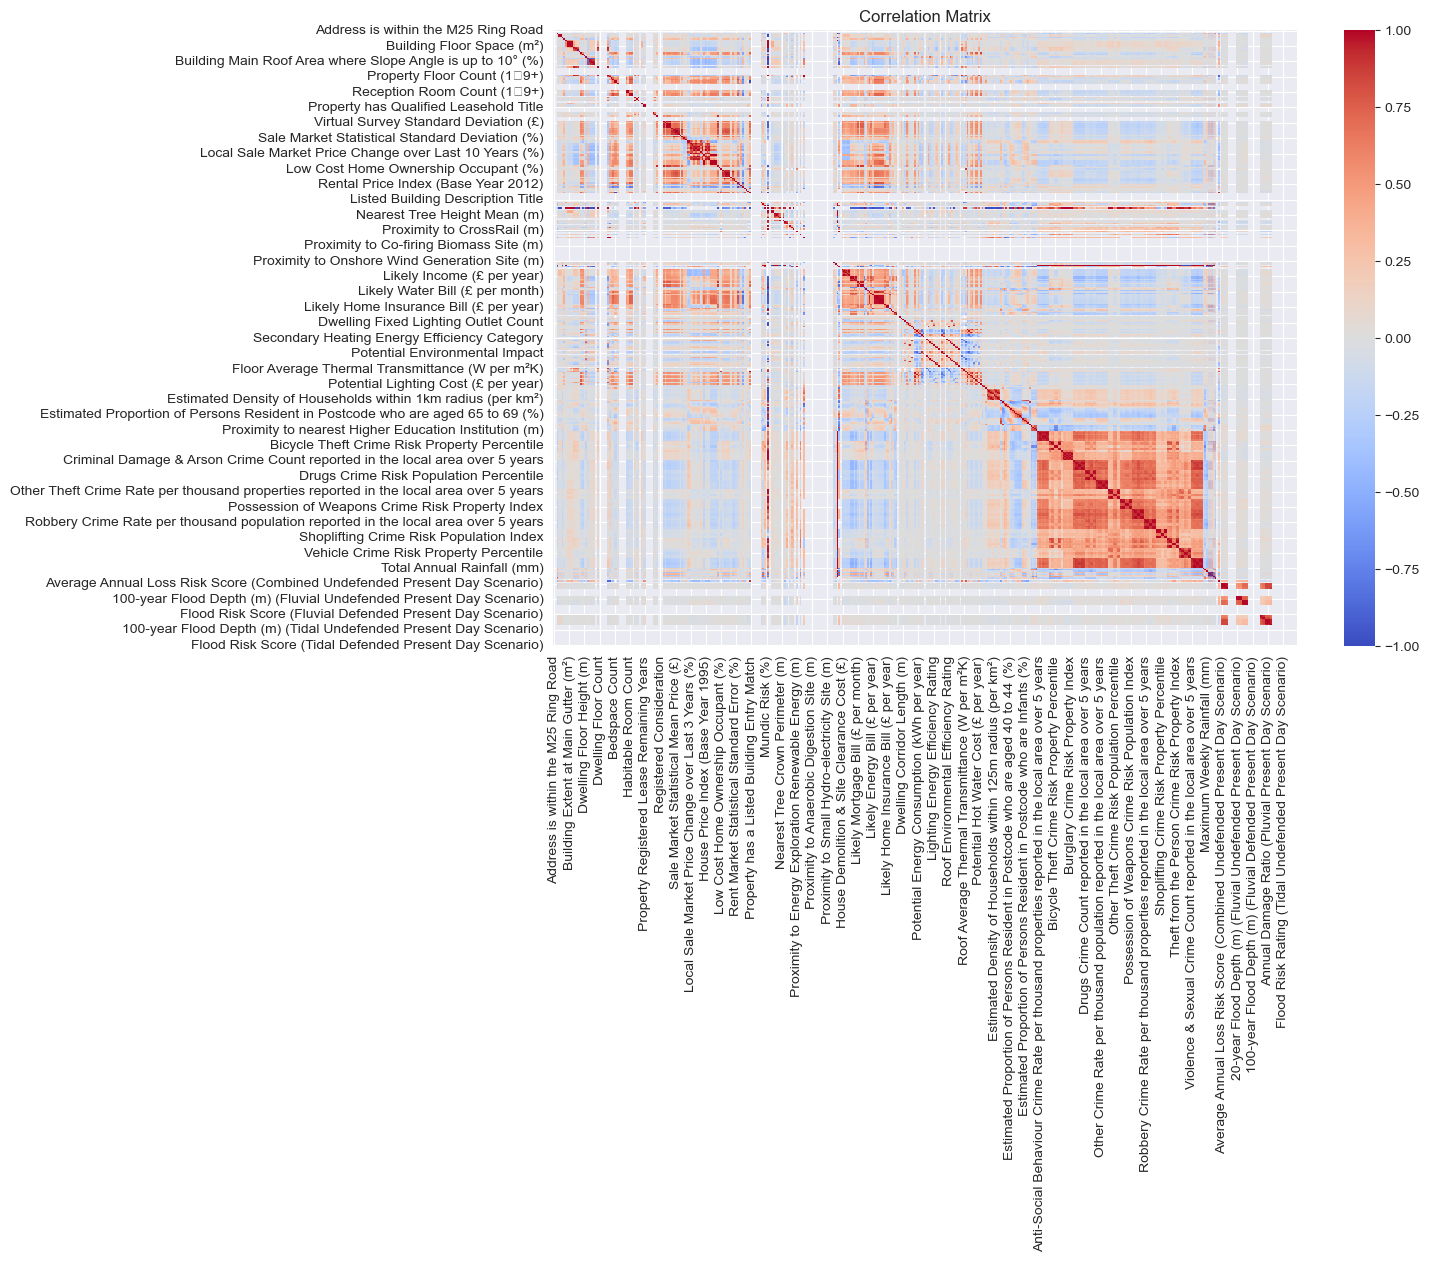

In [9]:
# Select only numeric columns for the correlation matrix
numeric_data = price_hubble_data.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
# Check unique values in each categorical column
for column in price_hubble_data.select_dtypes(include=['object', 'category']).columns:
    print(f"Value counts for {column}:\n", price_hubble_data[column].value_counts(), "\n")


Value counts for ORGANIZATION:
 ORGANIZATION
Post Office                         14
University of Oxford                13
Co-Operative Retail Services Ltd     7
Headington School                    7
Oxfordshire County Council           6
                                    ..
Hi Lo Jamaican Eating House          1
Maroc Deli                           1
Kashmirhalal Tandoori Restaurant     1
Indigo                               1
The Mole Inn                         1
Name: count, Length: 2118, dtype: int64 

Value counts for ADDRESS 0:
 ADDRESS 0
Flat 2                612
Flat 1                605
Flat 3                541
Flat 4                470
Flat 5                377
                     ... 
Flat 007                1
Manor House Annexe      1
Stable Block            1
Flat A-C                1
The Peepe               1
Name: count, Length: 1157, dtype: int64 

Value counts for ADDRESS 1:
 ADDRESS 1
Alice House               139
Summertown House          138
Arthur Sanctuary H

In [11]:
# Step 1: Select relevant columns with original names
columns_to_extract = [
    'Capital Valuation (£)',
    'Rental Price Valuation (£)',
    'Dwelling Floor Space (m²)',
    'Likely Income (£ per year)',
    'Geographic Coordinates (latitude longitude)',
    'POSTCODE'
]
valuation_data = price_hubble_data[columns_to_extract].copy()

# Step 2: Extract Latitude and Longitude
valuation_data[['Latitude', 'Longitude']] = (
    valuation_data['Geographic Coordinates (latitude longitude)']
    .str.split(' ', expand=True)
)

valuation_data['Latitude'] = pd.to_numeric(valuation_data['Latitude'], errors='coerce')
valuation_data['Longitude'] = pd.to_numeric(valuation_data['Longitude'], errors='coerce')

# Step 3: Calculate Valuations per m²
valuation_data['Capital Valuation (£/m²)'] = (
        valuation_data['Capital Valuation (£)'] / valuation_data['Dwelling Floor Space (m²)']
)
valuation_data['Rental Valuation (£/m²)'] = (
        valuation_data['Rental Price Valuation (£)'] / valuation_data['Dwelling Floor Space (m²)']
)

# Step 4: Calculate Income to Valuation Ratios
valuation_data['Income-to-Capital Ratio'] = (
        valuation_data['Likely Income (£ per year)'] / valuation_data['Capital Valuation (£)']
)
valuation_data['Income-to-Rental Ratio'] = (
        valuation_data['Likely Income (£ per year)'] / valuation_data['Rental Price Valuation (£)']
)

# Step 5: Clean the data
valuation_data_cleaned = valuation_data.dropna(
    subset=[
        'Capital Valuation (£)',
        'Rental Price Valuation (£)',
        'Dwelling Floor Space (m²)',
        'Latitude',
        'Longitude',
        'POSTCODE',
        'Likely Income (£ per year)'
    ]
)

# Reset the index for cleaned data
valuation_data_cleaned.reset_index(drop=True, inplace=True)

# Step 6: Rename columns with user-friendly names
valuation_data_cleaned.rename(columns={
    'Capital Valuation (£)': 'Capital Valuation (£)',
    'Rental Price Valuation (£)': 'Rental Valuation (£)',
    'Dwelling Floor Space (m²)': 'Floor Space (m²)',
    'Likely Income (£ per year)': 'Annual Income (£)',
    'Latitude': 'Latitude (°)',
    'Longitude': 'Longitude (°)',
    'POSTCODE': 'Postcode',
    'Capital Valuation (£/m²)': 'Capital Valuation (£/m²)',
    'Rental Valuation (£/m²)': 'Rental Valuation (£/m²)',
    'Income-to-Capital Ratio': 'Income-to-Capital Ratio',
    'Income-to-Rental Ratio': 'Income-to-Rental Ratio'
}, inplace=True)

# Step 7: Display the cleaned and renamed data
valuation_data_cleaned.head()

C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\4042844120.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valuation_data_cleaned.rename(columns={


,Capital Valuation (£),Rental Valuation (£),Floor Space (m²),Annual Income (£),Geographic Coordinates (latitude longitude),Postcode,Latitude (°),Longitude (°),Capital Valuation (£/m²),Rental Valuation (£/m²),Income-to-Capital Ratio,Income-to-Rental Ratio
0,434042.0,1345.0,77.0,71800.0,51.7646198 -1.2614062,OX2 6EX,51.764620,-1.261406,5636.909091,17.467532,0.165422,53.382900
1,997636.0,1345.0,78.0,71800.0,51.7644594 -1.2613801,OX2 6EX,51.764459,-1.261380,12790.205128,17.243590,0.071970,53.382900
2,784927.0,1345.0,88.0,66600.0,51.7615206 -1.2659198,OX2 6EN,51.761521,-1.265920,8919.625000,15.284091,0.084849,49.516729
3,855603.0,1345.0,83.0,66600.0,51.761556 -1.2658178,OX2 6EN,51.761556,-1.265818,10308.469880,16.204819,0.077840,49.516729
4,784927.0,1345.0,88.0,66600.0,51.7615737 -1.2657741,OX2 6EN,51.761574,-1.265774,8919.625000,15.284091,0.084849,49.516729


Correlation between Annual Income and Capital Valuation: 0.32
Correlation between Annual Income and Rental Valuation: -0.32


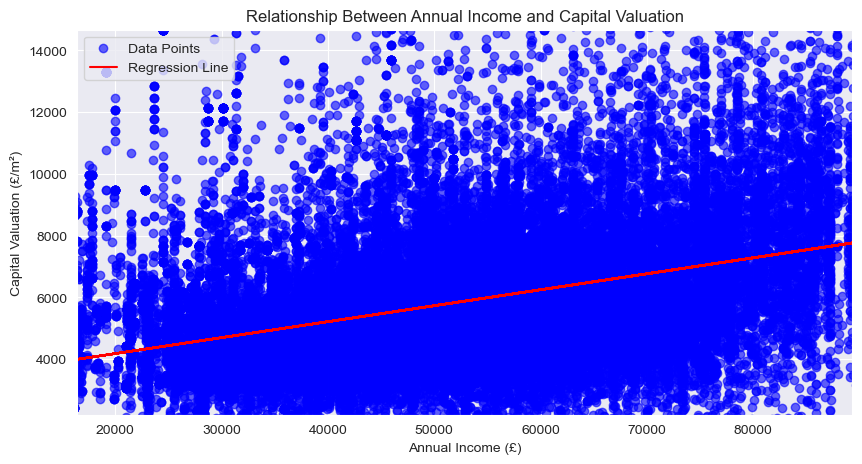

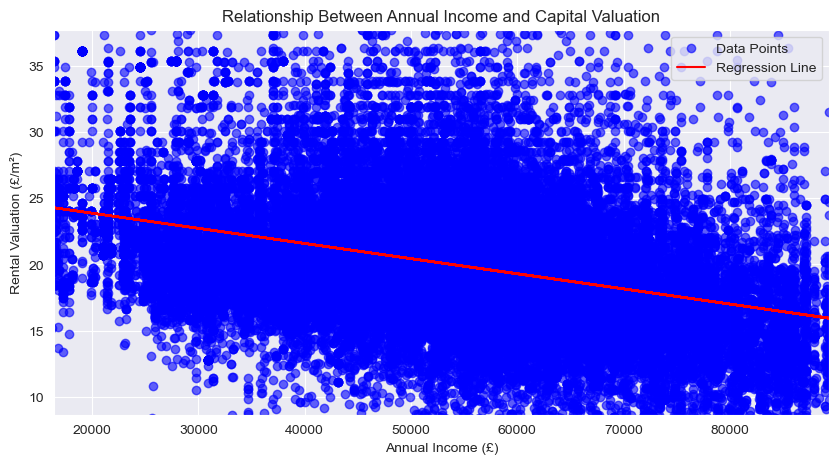

R² for Annual Income and Capital Valuation: 0.1008
R² for Annual Income and Capital Valuation: 0.1040


In [12]:
# Clean data: Remove rows with NaN or infinite values
filtered_data = valuation_data_cleaned[
    np.isfinite(valuation_data_cleaned['Annual Income (£)']) &
    np.isfinite(valuation_data_cleaned['Capital Valuation (£/m²)']) &
    np.isfinite(valuation_data_cleaned['Rental Valuation (£/m²)'])
    ].dropna()

# Calculate correlations
correlation_capital_income = filtered_data[['Annual Income (£)', 'Capital Valuation (£/m²)']].corr().iloc[0, 1]
correlation_rental_income = filtered_data[['Annual Income (£)', 'Rental Valuation (£/m²)']].corr().iloc[0, 1]

print(f"Correlation between Annual Income and Capital Valuation: {correlation_capital_income:.2f}")
print(f"Correlation between Annual Income and Rental Valuation: {correlation_rental_income:.2f}")

# Fit the regression model for Capital Valuation (£/m²)
X_capital = sm.add_constant(filtered_data['Annual Income (£)'])
y_capital = filtered_data['Capital Valuation (£/m²)']
model_capital = sm.OLS(y_capital, X_capital).fit()

# Axis limits for Capital Valuation plot
x_capital_limits = np.percentile(filtered_data['Annual Income (£)'], [1, 99])
y_capital_limits = np.percentile(filtered_data['Capital Valuation (£/m²)'], [1, 99])

# Plot Likely Income vs Capital Valuation (£/m²)
plt.figure(figsize=(10, 5))
plt.scatter(filtered_data['Annual Income (£)'], filtered_data['Capital Valuation (£/m²)'], color='blue', alpha=0.6, label='Data Points')
plt.plot(filtered_data['Annual Income (£)'], model_capital.predict(X_capital), color='red', label='Regression Line')
plt.title("Relationship Between Annual Income and Capital Valuation")
plt.xlabel("Annual Income (£)")
plt.ylabel("Capital Valuation (£/m²)")
plt.xlim(x_capital_limits)
plt.ylim(y_capital_limits)
plt.legend()
plt.show()

# Fit the regression model for Rental Valuation (£/m²)
X_rental = sm.add_constant(filtered_data['Annual Income (£)'])
y_rental = filtered_data['Rental Valuation (£/m²)']
model_rental = sm.OLS(y_rental, X_rental).fit()

# Axis limits for Rental Valuation plot
x_rental_limits = np.percentile(filtered_data['Annual Income (£)'], [1, 99])
y_rental_limits = np.percentile(filtered_data['Rental Valuation (£/m²)'], [1, 99])

# Plot Likely Income vs Rental Valuation (£/m²)
plt.figure(figsize=(10, 5))
plt.scatter(filtered_data['Annual Income (£)'], filtered_data['Rental Valuation (£/m²)'], color='blue', alpha=0.6, label='Data Points')
plt.plot(filtered_data['Annual Income (£)'], model_rental.predict(X_rental), color='red', label='Regression Line')
plt.title("Relationship Between Annual Income and Capital Valuation")
plt.xlabel("Annual Income (£)")
plt.ylabel("Rental Valuation (£/m²)")
plt.xlim(x_rental_limits)
plt.ylim(y_rental_limits)
plt.legend()
plt.show()

# Display R² values
print(f"R² for Annual Income and Capital Valuation: {model_capital.rsquared:.4f}")
print(f"R² for Annual Income and Capital Valuation: {model_rental.rsquared:.4f}")

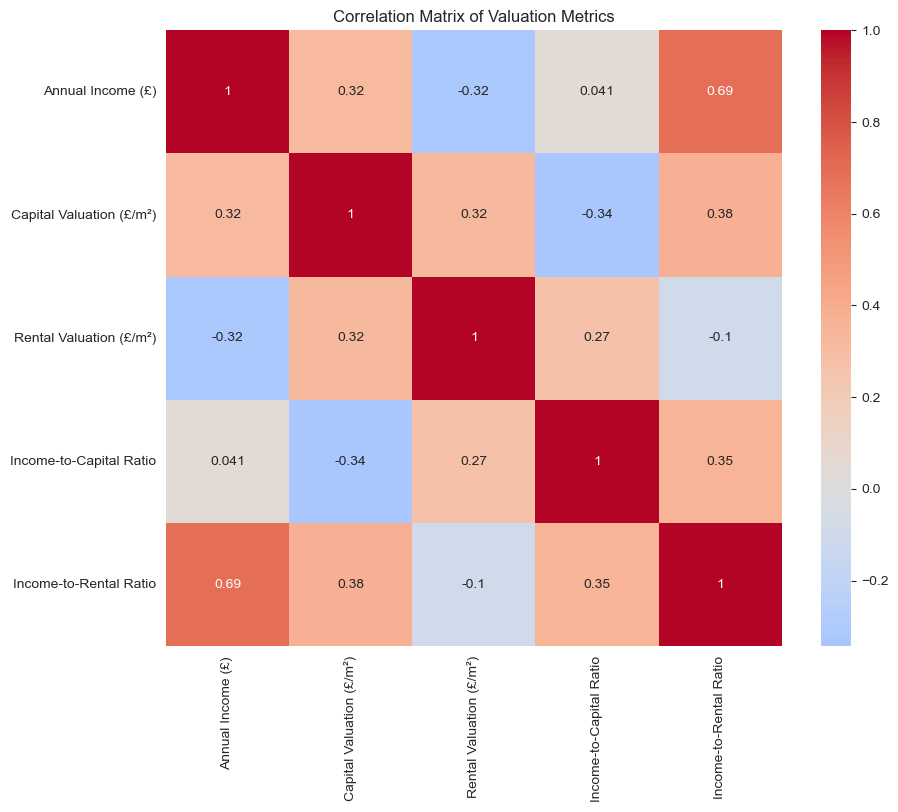

In [13]:
# Calculate correlations between the key metrics
correlation_matrix = valuation_data_cleaned[
    ['Annual Income (£)', 'Capital Valuation (£/m²)', 'Rental Valuation (£/m²)', 'Income-to-Capital Ratio', 'Income-to-Rental Ratio']].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title("Correlation Matrix of Valuation Metrics")
plt.show()

In [14]:
# Assuming valuation_data_cleaned is already loaded and contains the required columns.
# Generate 20 example values for each key metric
example_values = valuation_data_cleaned.sample(20)[
    ['Annual Income (£)',
     'Capital Valuation (£/m²)',
     'Rental Valuation (£/m²)',
     'Income-to-Capital Ratio',
     'Income-to-Rental Ratio']
]

# Display the example values
example_values

,Annual Income (£),Capital Valuation (£/m²),Rental Valuation (£/m²),Income-to-Capital Ratio,Income-to-Rental Ratio
2872,31400.0,7447.866667,24.066667,0.093688,28.993536
6870,50700.0,4992.012195,19.780488,0.123856,31.257707
39209,71700.0,5974.168317,23.732673,0.118828,29.912390
6309,73500.0,8740.035088,14.228070,0.073768,45.314427
42705,30700.0,3738.504950,23.732673,0.081305,12.807676
46940,58300.0,4363.239669,13.404959,0.110427,35.943280
7912,55600.0,6178.471429,23.171429,0.128557,34.278668
4979,60500.0,6442.873239,18.943662,0.132257,44.981413
8290,80900.0,4762.684848,7.263636,0.051473,33.750521
38694,37200.0,4156.975904,19.542169,0.107817,22.934649


In [15]:
# Set thresholds for overvaluation and undervaluation
undervalued_floor = 0.9
overvalued_ceiling = 0.1

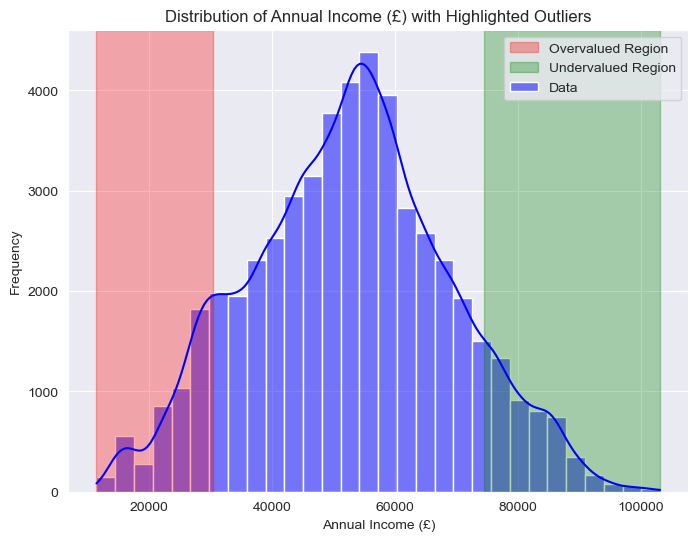

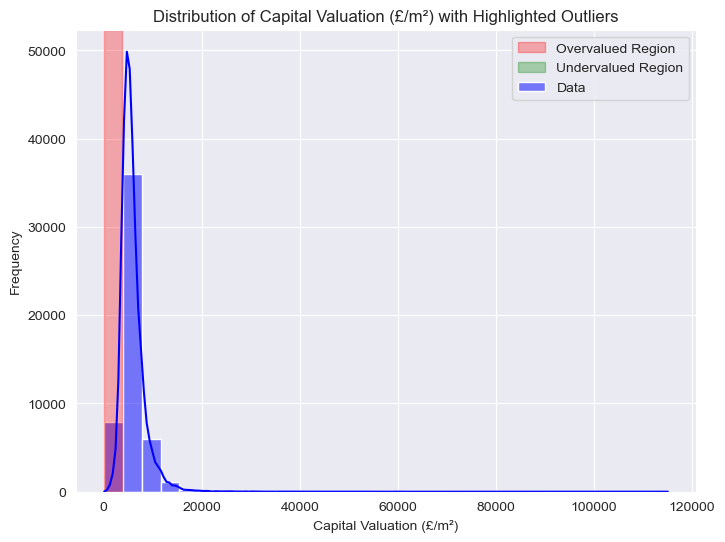

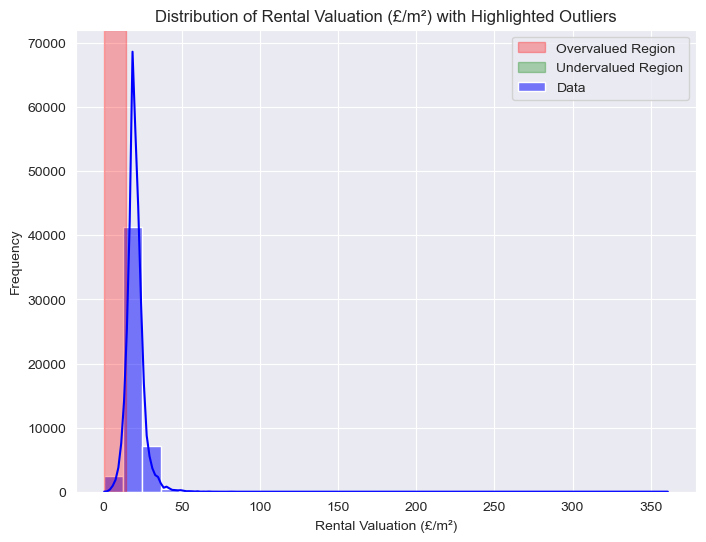

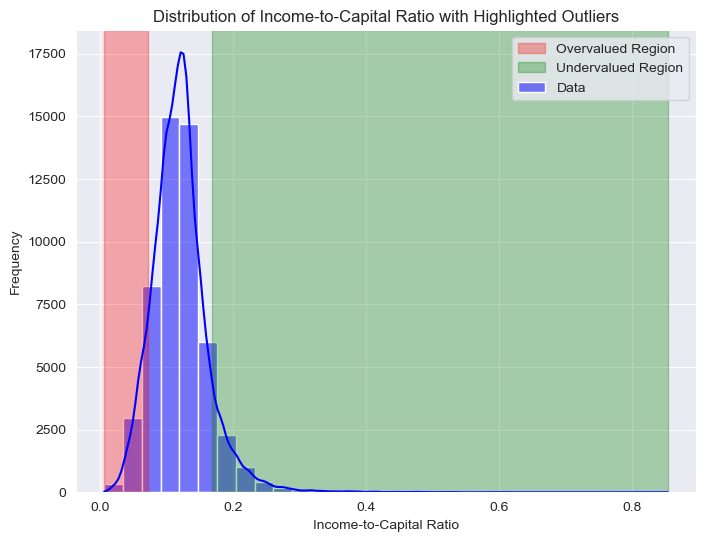

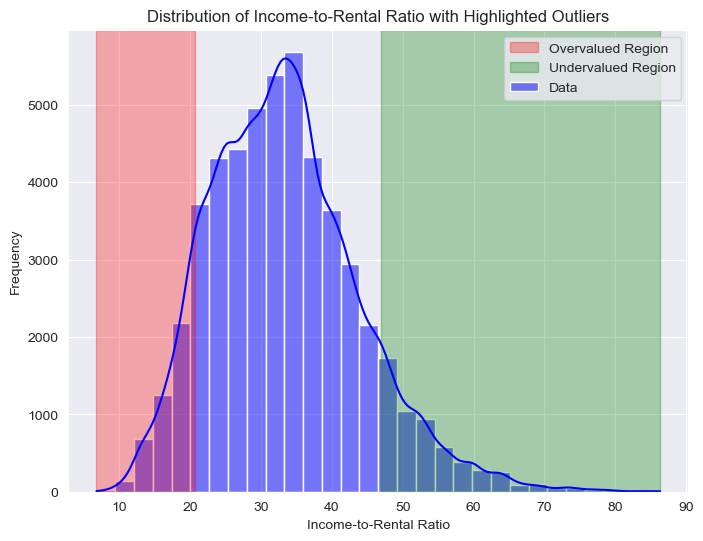

In [16]:
initial_metrics = ['Annual Income (£)', 'Capital Valuation (£/m²)', 'Rental Valuation (£/m²)', 'Income-to-Capital Ratio', 'Income-to-Rental Ratio']

#Plot distributions for each metric with outliers highlighted
for metric in initial_metrics:
    plt.figure(figsize=(8, 6))
    # Plot the histogram with KDE
    sns.histplot(valuation_data_cleaned[metric], kde=True, bins=30, color='blue', label='Data')

    # Highlight the "overvalued" region (below the 10th percentile)
    overvalued_threshold = valuation_data_cleaned[metric].quantile(overvalued_ceiling)
    plt.axvspan(valuation_data_cleaned[metric].min(), overvalued_threshold, color='red', alpha=0.3, label='Overvalued Region')

    # Highlight the "undervalued" region (above the 90th percentile)
    undervalued_threshold = valuation_data_cleaned[metric].quantile(undervalued_floor)
    plt.axvspan(undervalued_threshold, valuation_data_cleaned[metric].max(), color='green', alpha=0.3, label='Undervalued Region')

    # Add titles, labels, and legend
    plt.title(f"Distribution of {metric} with Highlighted Outliers")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.legend(loc="upper right")
    plt.show()

In [17]:
# Load the ONS boundaries dataset
ons_boundaries_path = "data/raw/district_boundaries.geojson"
uk_boundaries = gpd.read_file(ons_boundaries_path)

# Get the index of the filtered dataset for LAD24NM = "Oxford"
oxford_index = uk_boundaries[uk_boundaries['LAD24NM'] == "Oxford"].index[0]

# Select the row and 10 before and after
rows_to_display = uk_boundaries.iloc[max(0, oxford_index-10):oxford_index+11]

rows_to_display

,FID,LAD24CD,LAD24NM,LAD24NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
167,168,E07000148,Norwich,,622355,309773,1.284979,52.64013,de93d2ae-c4a6-4016-9596-058a9c66eda9,"POLYGON ((1.32529 52.62318, 1.32965 52.62420, ..."
168,169,E07000149,South Norfolk,,628991,295822,1.373247,52.51217,beb6a992-f05c-4b70-b40e-4ddec038105c,"POLYGON ((1.27624 52.59923, 1.28552 52.59589, ..."
169,170,E07000170,Ashfield,,450035,355843,-1.254220,53.09747,927f5e2b-19f4-43b1-b6d8-e5b5a8f95586,"POLYGON ((-1.25993 53.16448, -1.25532 53.15462..."
170,171,E07000171,Bassetlaw,,468073,384835,-0.978700,53.35604,2c51b0db-0ead-4627-8cd4-99ebc1270219,"POLYGON ((-0.79748 53.45506, -0.82052 53.44075..."
171,172,E07000172,Broxtowe,,449829,341891,-1.259440,52.97208,53555ab8-2230-48b0-a8ca-89b746c75de3,"POLYGON ((-1.22519 53.00814, -1.21911 52.99144..."
172,173,E07000173,Gedling,,459184,347811,-1.119070,53.02434,77a85481-8346-4958-b8a3-dfde3c5f739b,"POLYGON ((-1.00709 52.98546, -1.01655 52.98024..."
173,174,E07000174,Mansfield,,455047,363637,-1.178040,53.16703,da379aa9-7981-466a-9826-4115e723efe5,"POLYGON ((-1.17789 53.11481, -1.23992 53.13959..."
174,175,E07000175,Newark and Sherwood,,470624,357451,-0.946430,53.10960,50a242e0-5a19-454f-b1ce-f55666b81ff5,"POLYGON ((-0.66658 53.23970, -0.67587 53.21764..."
175,176,E07000176,Rushcliffe,,466609,335453,-1.010930,52.91240,cccc95d5-5e88-42a2-beeb-488b822ea2bc,"POLYGON ((-0.82002 52.96046, -0.83391 52.94588..."
176,177,E07000177,Cherwell,,449301,221199,-1.285060,51.88718,a5d757df-72c4-4149-8780-7c8e08b1b9b2,"POLYGON ((-1.11809 52.01543, -1.05313 52.00245..."


<Figure size 1000x800 with 0 Axes>

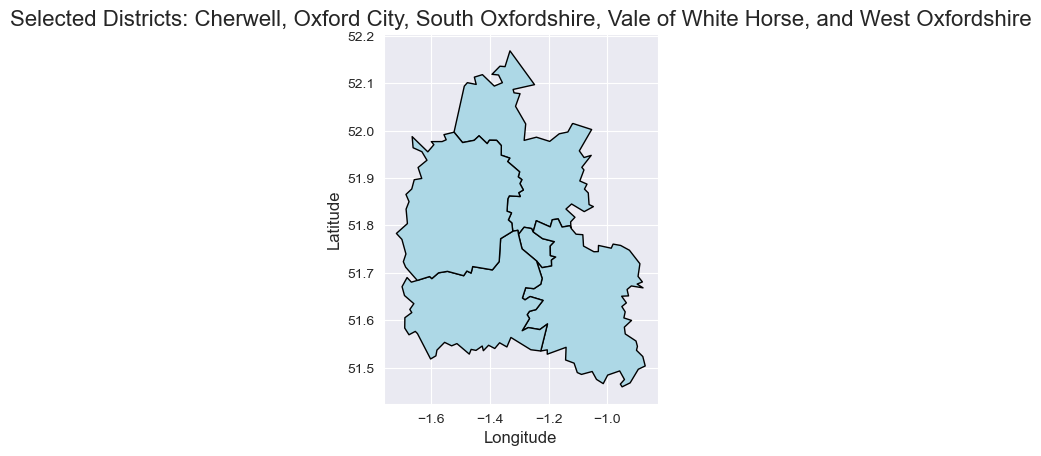

Selected districts saved to data/processed/selected_districts.geojson


In [18]:
# Filter for districts E07000178, E07000179, E07000181
district_ids = ["E07000177", "E07000178", "E07000179", "E07000180", "E07000181"]
filtered_districts = uk_boundaries[uk_boundaries['LAD24CD'].isin(district_ids)]

# Plot the selected districts
plt.figure(figsize=(10, 8))
ax = filtered_districts.plot(edgecolor="black", facecolor="lightblue", linewidth=1)

plt.title("Selected Districts: Cherwell, Oxford City, South Oxfordshire, Vale of White Horse, and West Oxfordshire", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.show()

# Save the GeoJSON
selected_districts_path = "data/processed/selected_districts.geojson"
filtered_districts.to_file(selected_districts_path, driver="GeoJSON")
print(f"Selected districts saved to {selected_districts_path}")

C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\745376481.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = undervalued_gdf.geometry.distance(centroid).idxmin()
C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\745376481.py:73: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax_undervalued_overvalued.legend(loc='upper right', fontsize=10)


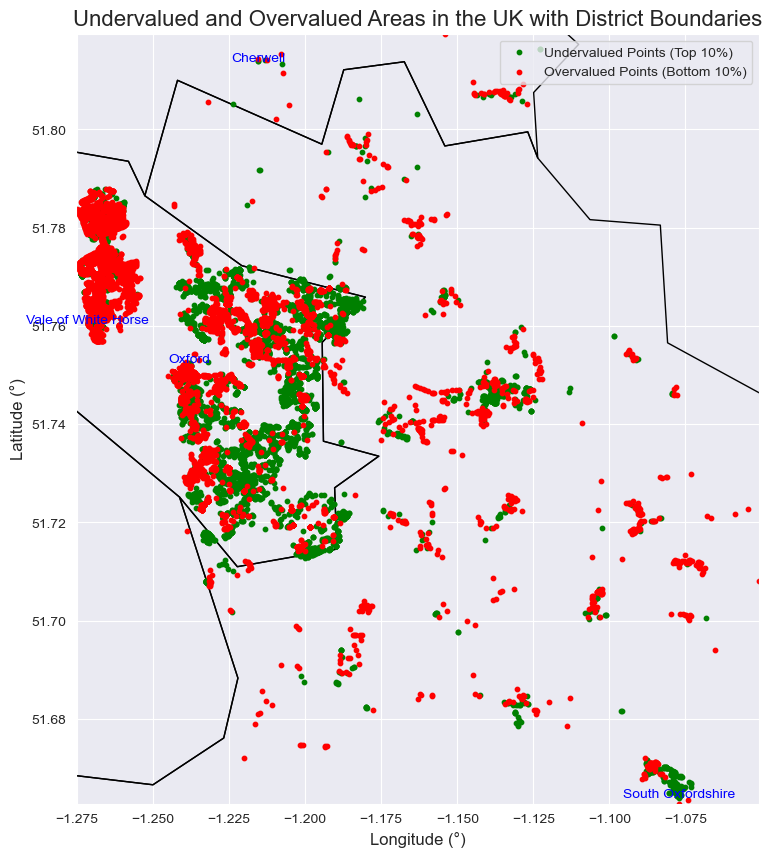

The static map has been saved as outputs/undervalued_overvalued_points_map.png.


In [19]:
# Step 1: Load the GeoJSON file containing district boundaries
districts_geojson_path = "data/processed/selected_districts.geojson"
selected_districts = gpd.read_file(districts_geojson_path)

# Step 2: Define the percentile thresholds
undervalued_threshold = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(undervalued_floor)
overvalued_threshold = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(overvalued_ceiling)

# Filter for undervalued points (above the 90th percentile)
undervalued_points = valuation_data_cleaned[valuation_data_cleaned['Income-to-Capital Ratio'] > undervalued_threshold]

# Filter for overvalued points (below the 10th percentile)
overvalued_points = valuation_data_cleaned[valuation_data_cleaned['Income-to-Capital Ratio'] < overvalued_threshold]

# Step 3: Convert points to GeoDataFrames
undervalued_gdf = gpd.GeoDataFrame(
    undervalued_points,
    geometry=gpd.points_from_xy(undervalued_points['Longitude (°)'], undervalued_points['Latitude (°)']),
    crs="EPSG:4326"
)

overvalued_gdf = gpd.GeoDataFrame(
    overvalued_points,
    geometry=gpd.points_from_xy(overvalued_points['Longitude (°)'], overvalued_points['Latitude (°)']),
    crs="EPSG:4326"
)

# Step 4: Calculate the bounding box for both sets of points
bbox_undervalued_overvalued = gpd.GeoDataFrame(pd.concat([undervalued_gdf, overvalued_gdf])).total_bounds  # [minx, miny, maxx, maxy]

# Step 5: Filter districts within the bounding box
selected_districts_undervalued_overvalued = selected_districts.cx[bbox_undervalued_overvalued[0]:bbox_undervalued_overvalued[2], bbox_undervalued_overvalued[1]:bbox_undervalued_overvalued[3]]

# Step 6: Plot the districts and undervalued/overvalued points
fig_undervalued_overvalued, ax_undervalued_overvalued = plt.subplots(figsize=(12, 10))

# Set the extent of the map to focus on the area of interest
ax_undervalued_overvalued.set_xlim(bbox_undervalued_overvalued[0], bbox_undervalued_overvalued[2])  # minx, maxx
ax_undervalued_overvalued.set_ylim(bbox_undervalued_overvalued[1], bbox_undervalued_overvalued[3])  # miny, maxy

# Plot district boundaries
selected_districts_undervalued_overvalued.plot(ax=ax_undervalued_overvalued, edgecolor="black", facecolor="none", linewidth=1, label="District Boundaries")

# Add district labels using LAD24NM, placed near points
for idx, row in selected_districts_undervalued_overvalued.iterrows():
    centroid = row.geometry.centroid
    nearest_point = undervalued_gdf.geometry.distance(centroid).idxmin()
    label_x, label_y = undervalued_gdf.geometry[nearest_point].x, undervalued_gdf.geometry[nearest_point].y
    ax_undervalued_overvalued.text(label_x, label_y, row['LAD24NM'], fontsize=10, ha='center', color='blue')

# Plot undervalued points in green
undervalued_gdf.plot(
    ax=ax_undervalued_overvalued,
    color='green',
    markersize=10,
    label="Undervalued Points (Top 10%)"
)

# Plot overvalued points in red
overvalued_gdf.plot(
    ax=ax_undervalued_overvalued,
    color='red',
    markersize=10,
    label="Overvalued Points (Bottom 10%)"
)

# Add titles and labels
plt.title("Undervalued and Overvalued Areas in the UK with District Boundaries", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)

# Add legend
ax_undervalued_overvalued.legend(loc='upper right', fontsize=10)

# Save the static map as an image
outliers_map_path = "outputs/undervalued_overvalued_points_map.png"
plt.savefig(outliers_map_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"The static map has been saved as {outliers_map_path}.")

In [20]:
# Step 1: Initialize a Folium map with the Positron basemap
map_undervalued_overvalued = folium.Map(location=[55.3781, -3.4360], zoom_start=6, tiles="CartoDB positron")

# Step 2: Add the districts GeoJSON to the map
folium.GeoJson(
    selected_districts,
    name="District Boundaries",
    style_function=lambda x: {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0.1
    },
    highlight_function=lambda x: {
        "color": "red",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(fields=["LAD24NM"], aliases=["District:"], localize=True)  # Use LAD24NM for labels
).add_to(map_undervalued_overvalued)

# Step 3: Add undervalued points to the map in green
for _, row in undervalued_points.iterrows():
    folium.CircleMarker(
        location=(row['Latitude (°)'], row['Longitude (°)']),
        radius=5,
        color="green",  # Use green for undervalued points
        fill=True,
        fill_color="green",
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Postcode:</b> {row['Postcode']}<br>"
            f"<b>Income to Capital Ratio:</b> {row['Income-to-Capital Ratio']:.2f}",
            max_width=300
        )
    ).add_to(map_undervalued_overvalued)

# Step 4: Add overvalued points to the map in red
for _, row in overvalued_points.iterrows():
    folium.CircleMarker(
        location=(row['Latitude (°)'], row['Longitude (°)']),
        radius=5,
        color="red",  # Use red for overvalued points
        fill=True,
        fill_color="red",
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Postcode:</b> {row['Postcode']}<br>"
            f"<b>Income to Capital Ratio:</b> {row['Income-to-Capital Ratio']:.2f}",
            max_width=300
        )
    ).add_to(map_undervalued_overvalued)

# Step 5: Add title and additional information as HTML
title_html_outliers = f'''
    <h3 align="center" style="font-size:16px"><b>Undervalued and Overvalued Areas in the UK with District Boundaries</b></h3>
    <p align="center" style="font-size:12px">
    This map shows areas where the Income to Capital Valuation Ratio is significantly 
    above the 90th percentile (undervalued in green) or below the 10th percentile (overvalued in red).
    </p>
'''
map_undervalued_overvalued.get_root().html.add_child(folium.Element(title_html_outliers))

# Step 6: Save the map as an HTML file
outliers_map_html_path = "outputs/undervalued_overvalued_points_map.html"
map_undervalued_overvalued.save(outliers_map_html_path)

print(f"The map with district boundaries has been saved as '{outliers_map_html_path}'.")

The map with district boundaries has been saved as 'outputs/undervalued_overvalued_points_map.html'.


C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\1587165989.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valuation_data_cleaned['Is_Undervalued'] = valuation_data_cleaned['Income-to-Capital Ratio'] > undervalued_threshold


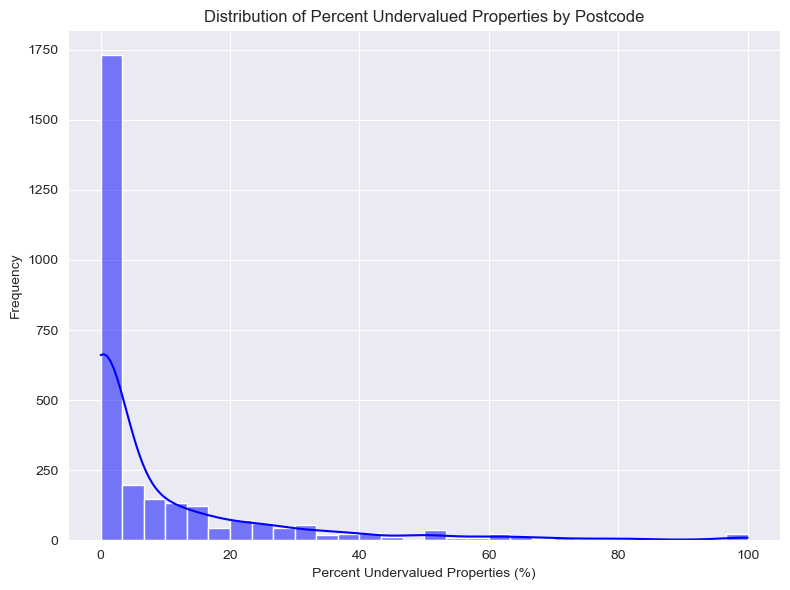

C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\1587165989.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = postcode_undervaluation_gdf.geometry.distance(centroid).idxmin()


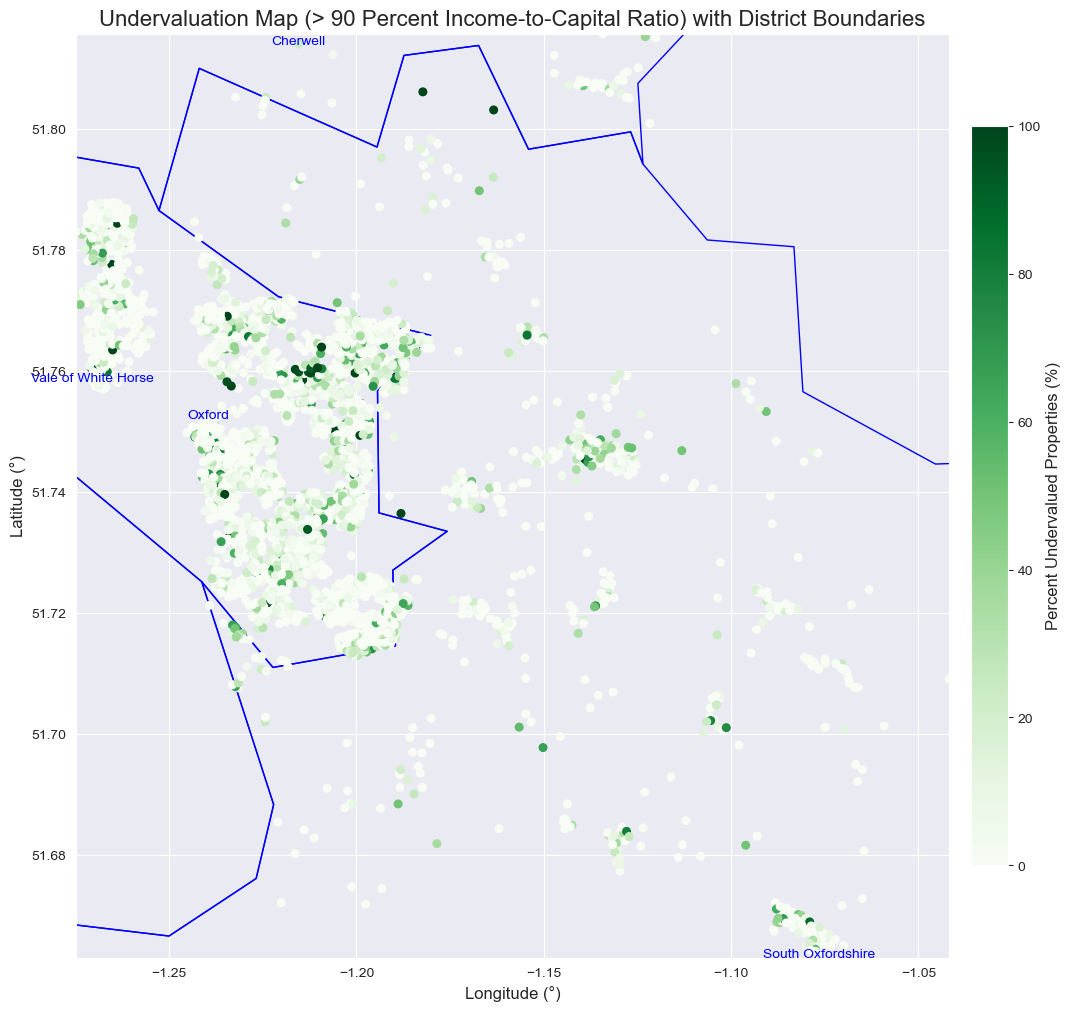

The static map has been saved as outputs/undervaluation_map_postcode.png.


In [21]:
# Step 1: Mark undervalued properties based on threshold
valuation_data_cleaned['Is_Undervalued'] = valuation_data_cleaned['Income-to-Capital Ratio'] > undervalued_threshold

# Step 2: Calculate undervaluation statistics by postcode
postcode_undervaluation_stats = (
    valuation_data_cleaned.groupby('Postcode')
    .agg(
        Percent_Undervalued=('Is_Undervalued', 'mean'),  # Percentage of properties undervalued
        Average_Latitude=('Latitude (°)', 'mean'),      # Average latitude of the postcode group
        Average_Longitude=('Longitude (°)', 'mean')     # Average longitude of the postcode group
    )
    .reset_index()
)

# Convert percentages to a more readable format
postcode_undervaluation_stats['Percent_Undervalued'] *= 100

# Step 3: Plot the distribution of undervaluation percentages
plt.figure(figsize=(8, 6))
sns.histplot(postcode_undervaluation_stats['Percent_Undervalued'], kde=True, bins=30, color='blue')
plt.title("Distribution of Percent Undervalued Properties by Postcode")
plt.xlabel("Percent Undervalued Properties (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Step 4: Convert postcode data to GeoDataFrame
postcode_undervaluation_gdf = gpd.GeoDataFrame(
    postcode_undervaluation_stats,
    geometry=gpd.points_from_xy(
        postcode_undervaluation_stats['Average_Longitude'], postcode_undervaluation_stats['Average_Latitude']
    ),
    crs="EPSG:4326"
)

# Normalize undervaluation percentages for colormap
norm_postcode = Normalize(vmin=postcode_undervaluation_gdf['Percent_Undervalued'].min(),
                 vmax=postcode_undervaluation_gdf['Percent_Undervalued'].max())
cmap_postcode = plt.cm.Greens
scalar_map_postcode = ScalarMappable(cmap=cmap_postcode, norm=norm_postcode)

# Calculate bounding box for resizing the map view
bbox_postcode = postcode_undervaluation_gdf.total_bounds  # [minx, miny, maxx, maxy]
selected_districts_postcode = selected_districts.cx[bbox_postcode[0]:bbox_postcode[2], bbox_postcode[1]:bbox_postcode[3]]

# Step 5: Plot the map
fig_postcode, ax_postcode = plt.subplots(figsize=(14, 12))

# Set map extent to focus on data
ax_postcode.set_xlim(bbox_postcode[0], bbox_postcode[2])  # minx, maxx
ax_postcode.set_ylim(bbox_postcode[1], bbox_postcode[3])  # miny, maxy

# Plot district boundaries
selected_districts_postcode.plot(ax=ax_postcode, edgecolor='blue', facecolor='none', linewidth=1, label="District Boundaries")

# Add district labels near data points
for idx, row in selected_districts_postcode.iterrows():
    centroid = row.geometry.centroid
    nearest_point = postcode_undervaluation_gdf.geometry.distance(centroid).idxmin()
    label_x, label_y = postcode_undervaluation_gdf.geometry[nearest_point].x, postcode_undervaluation_gdf.geometry[nearest_point].y
    ax_postcode.text(label_x, label_y, row['LAD24NM'], fontsize=10, ha='center', color='blue')

# Plot undervaluation points
postcode_undervaluation_gdf.plot(
    ax=ax_postcode,
    color=postcode_undervaluation_gdf['Percent_Undervalued'].map(lambda x: cmap_postcode(norm_postcode(x))),
    markersize=30,
    label="Percent Undervalued Properties (%)"
)

# Add a title describing the threshold used
threshold_percentile = int(undervalued_floor * 100)
plt.title(f"Undervaluation Map (> {threshold_percentile} Percent Income-to-Capital Ratio) with District Boundaries", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)

# Add a color bar for the percentage of undervaluation
colorbar_postcode = plt.colorbar(scalar_map_postcode, ax=ax_postcode, orientation='vertical', shrink=0.8, pad=0.02)
colorbar_postcode.set_label("Percent Undervalued Properties (%)", fontsize=12)

# Save the map to a file
output_path_postcode = "outputs/undervaluation_map_postcode.png"
plt.savefig(output_path_postcode, dpi=300, bbox_inches='tight')
plt.show()

print(f"The static map has been saved as {output_path_postcode}.")

In [22]:
# Step 1: Define a colormap based on the Percent_Undervalued values
colormap_postcode = linear.Greens_09.scale(
    postcode_undervaluation_stats['Percent_Undervalued'].min(),
    postcode_undervaluation_stats['Percent_Undervalued'].max()
)

# Step 2: Initialize a Folium map with the Positron basemap
map_postcode = folium.Map(location=[55.3781, -3.4360], zoom_start=6, tiles="CartoDB Positron")

# Step 3: Add the districts GeoJSON to the map with LAD24NM as labels
folium.GeoJson(
    selected_districts,
    name="District Boundaries",
    style_function=lambda x: {
        "color": "blue",
        "weight": 2,
        "fillOpacity": 0.1
    },
    highlight_function=lambda x: {
        "color": "darkblue",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(fields=["LAD24NM"], aliases=["District:"], localize=True)
).add_to(map_postcode)

# Step 4: Add undervaluation points with percentages to the map
for _, row in postcode_undervaluation_stats.iterrows():
    folium.CircleMarker(
        location=(row['Average_Latitude'], row['Average_Longitude']),
        radius=6,
        color=colormap_postcode(row['Percent_Undervalued']),
        fill=True,
        fill_color=colormap_postcode(row['Percent_Undervalued']),
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>Postcode:</b> {row['Postcode']}<br>"
            f"<b>Percent Undervalued:</b> {row['Percent_Undervalued']:.2f}%",
            max_width=300
        )
    ).add_to(map_postcode)

# Step 5: Add the colormap legend
colormap_postcode.caption = "Percent Undervalued Properties (%)"
map_postcode.add_child(colormap_postcode)

# Step 6: Update the map title dynamically with the threshold percentile
title_html_postcode = f'''
    <h3 align="center" style="font-size:16px"><b>UK Property Undervaluation Map</b></h3>
    <p align="center" style="font-size:12px">Properties above the <b>{threshold_percentile}%</b> Income-to-Capital Ratio threshold are highlighted.</p>
'''
map_postcode.get_root().html.add_child(folium.Element(title_html_postcode))

# Step 7: Save the map as an HTML file
output_path_html_postcode = "outputs/undervaluation_map_postcode.html"
map_postcode.save(output_path_html_postcode)

print(f"Map with undervaluation percentage and districts saved as '{output_path_html_postcode}'")

Map with undervaluation percentage and districts saved as 'outputs/undervaluation_map_postcode.html'


C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\1262925628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valuation_data_cleaned['Postcode_Group'] = valuation_data_cleaned['Postcode'].str[:-1]
C:\Users\Sulay\AppData\Local\Temp\ipykernel_22484\1262925628.py:49: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = postcode_group_undervaluation_gdf.geometry.distance(centroid).idxmin()


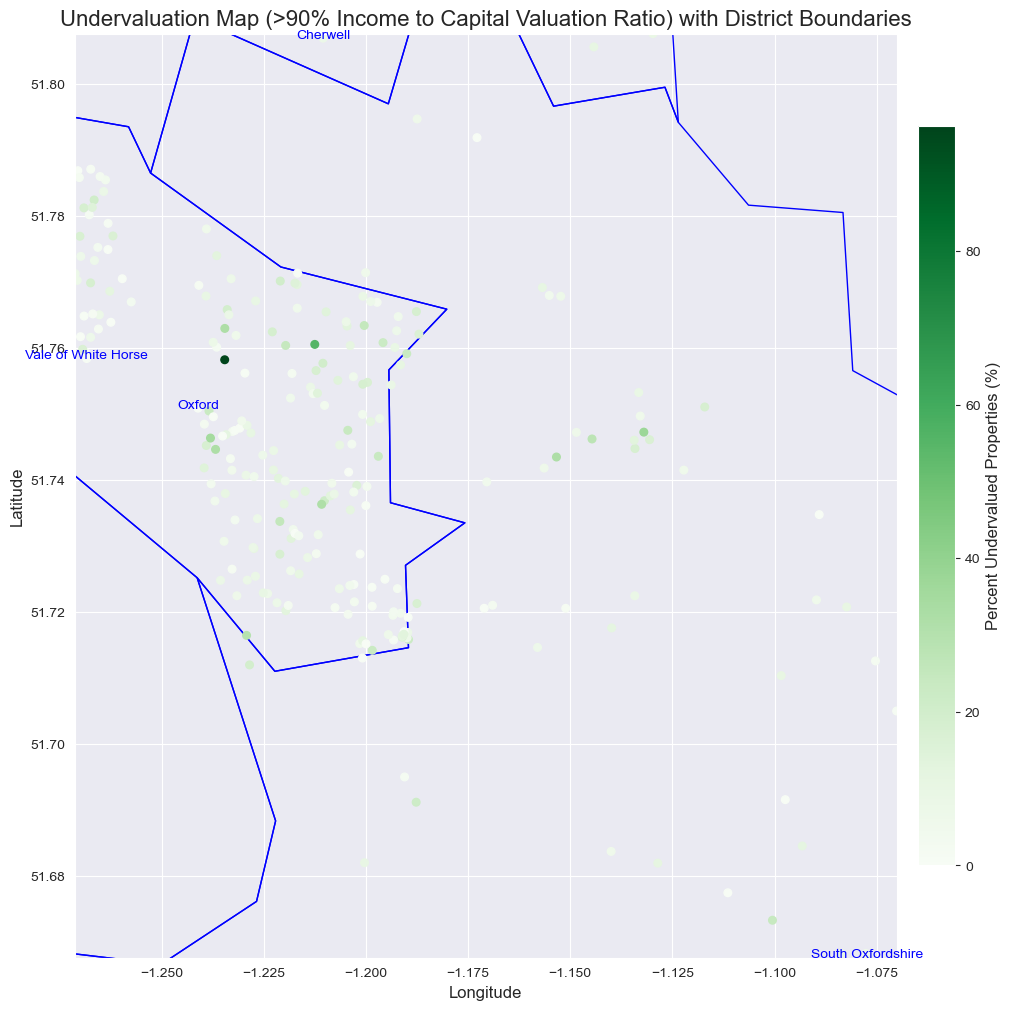

The static map has been saved as outputs/undervaluation_map_postcode_group.png.


In [23]:
# Define postcode groups
valuation_data_cleaned['Postcode_Group'] = valuation_data_cleaned['Postcode'].str[:-1]

# Step 1: Calculate percentage of undervalued properties within each postcode group
postcode_group_undervaluation_stats = (
    valuation_data_cleaned.groupby('Postcode_Group')
    .agg(
        Percent_Undervalued=('Is_Undervalued', 'mean'),
        Average_Latitude=('Latitude (°)', 'mean'),
        Average_Longitude=('Longitude (°)', 'mean')
    )
    .reset_index()
)

# Convert undervaluation percentage to percentage format
postcode_group_undervaluation_stats['Percent_Undervalued'] *= 100

# Step 2: Convert undervaluation data to GeoDataFrame
postcode_group_undervaluation_gdf = gpd.GeoDataFrame(
    postcode_group_undervaluation_stats,
    geometry=gpd.points_from_xy(postcode_group_undervaluation_stats['Average_Longitude'],
                                postcode_group_undervaluation_stats['Average_Latitude']),
    crs="EPSG:4326"
)

# Normalize undervaluation percentage for the colormap
norm_postcode_group = Normalize(vmin=postcode_group_undervaluation_gdf['Percent_Undervalued'].min(),
                 vmax=postcode_group_undervaluation_gdf['Percent_Undervalued'].max())
cmap_postcode_group = plt.cm.Greens
scm_postcode_group = ScalarMappable(cmap=cmap_postcode_group, norm=norm_postcode_group)

# Step 3: Calculate bounding box to resize map view
bbox_postcode_group = postcode_group_undervaluation_gdf.total_bounds  # [minx, miny, maxx, maxy]
selected_districts_postcode_group = selected_districts.cx[bbox_postcode_group[0]:bbox_postcode_group[2], bbox_postcode_group[1]:bbox_postcode_group[3]]

# Step 4: Plot the map
fig_postcode_group, ax_postcode_group = plt.subplots(figsize=(14, 12))

# Set the extent of the map
ax_postcode_group.set_xlim(bbox_postcode_group[0], bbox_postcode_group[2])  # minx, maxx
ax_postcode_group.set_ylim(bbox_postcode_group[1], bbox_postcode_group[3])  # miny, maxy

# Plot district boundaries
selected_districts_postcode_group.plot(ax=ax_postcode_group, edgecolor='blue', facecolor='none', linewidth=1, label="District Boundaries")

# Add district labels near data points
for idx, row in selected_districts_postcode_group.iterrows():
    centroid = row.geometry.centroid
    nearest_point = postcode_group_undervaluation_gdf.geometry.distance(centroid).idxmin()
    label_x, label_y = postcode_group_undervaluation_gdf.geometry[nearest_point].x, postcode_group_undervaluation_gdf.geometry[nearest_point].y
    ax_postcode_group.text(label_x, label_y, row['LAD24NM'], fontsize=10, ha='center', color='blue')

# Plot undervaluation points
postcode_group_undervaluation_gdf.plot(
    ax=ax_postcode_group,
    color=postcode_group_undervaluation_gdf['Percent_Undervalued'].map(lambda x: cmap_postcode_group(norm_postcode_group(x))),
    markersize=30,
    label="Undervaluation Points"
)

# Add title reflecting the threshold
plt.title(f"Undervaluation Map (>{threshold_percentile}% Income to Capital Valuation Ratio) with District Boundaries", fontsize=16)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Add a color bar
cbar_postcode_group = plt.colorbar(scm_postcode_group, ax=ax_postcode_group, orientation='vertical', shrink=0.8, pad=0.02)
cbar_postcode_group.set_label("Percent Undervalued Properties (%)", fontsize=12)

# Save the map as an image
output_path_postcode_group = "outputs/undervaluation_map_postcode_group.png"
plt.savefig(output_path_postcode_group, dpi=300, bbox_inches='tight')
plt.show()

print(f"The static map has been saved as {output_path_postcode_group}.")

In [24]:
# Step 1: Initialize a Folium map with the Positron basemap
map_postcode_group = folium.Map(location=[55.3781, -3.4360], zoom_start=6, tiles="CartoDB Positron")

# Step 1: Create a continuous color scale for the raw percentage scores
colormap_postcode_group = linear.YlGnBu_09.scale(
    postcode_group_undervaluation_stats['Percent_Undervalued'].min(),
    postcode_group_undervaluation_stats['Percent_Undervalued'].max()
)
colormap_postcode_group.caption = 'Percent Undervalued Properties (%)'

# Step 2: Add undervaluation points directly to the map as a dotmap
for _, row in postcode_group_undervaluation_stats.iterrows():
    score = row['Percent_Undervalued']
    color = colormap_postcode_group(score)

    # Display Postcode Group directly
    postcode_group = row['Postcode_Group']

    # Add points as CircleMarker directly to the map
    folium.CircleMarker(
        location=(row['Average_Latitude'], row['Average_Longitude']),
        radius=4,  # Smaller radius for dotmap
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.8,
        popup=(f"<b>Postcode Group:</b> {postcode_group}<br>"
               f"<b>Percent Undervalued:</b> {score:.2f}%")
    ).add_to(map_postcode_group)

# Step 3: Add the selected districts GeoJSON to the map
folium.GeoJson(
    selected_districts,
    name="District Boundaries",
    style_function=lambda x: {
        "color": "blue",
        "weight": 2,
        "fillOpacity": 0.1
    },
    highlight_function=lambda x: {
        "color": "darkblue",
        "weight": 3
    },
    tooltip=folium.GeoJsonTooltip(fields=["LAD24NM"], aliases=["District:"], localize=True)
).add_to(map_postcode_group)

# Step 4: Add the colormap legend
colormap_postcode_group.caption = "Percent Undervalued Properties (%)"
map_postcode_group.add_child(colormap_postcode_group)

# Step 5: Add a dynamic title for the map reflecting the threshold percentile
title_html_postcode_group = f"""
    <h3 align="center" style="font-size:16px">
    <b>UK Property Undervaluation Map (>{threshold_percentile}% Income to Capital Valuation Ratio)</b>
    </h3>
    <p align="center" style="font-size:12px">
    Percent undervalued properties are plotted with district boundaries highlighted.
    </p>
"""
map_postcode_group.get_root().html.add_child(folium.Element(title_html_postcode_group))

# Step 6: Save map to an HTML file
output_path_html_postcode_group = "outputs/undervaluation_map_postcode_group.html"
map_postcode_group.save(output_path_html_postcode_group)

print(f"The map has been saved to {output_path_html_postcode_group}")

The map has been saved to outputs/undervaluation_map_postcode_group.html


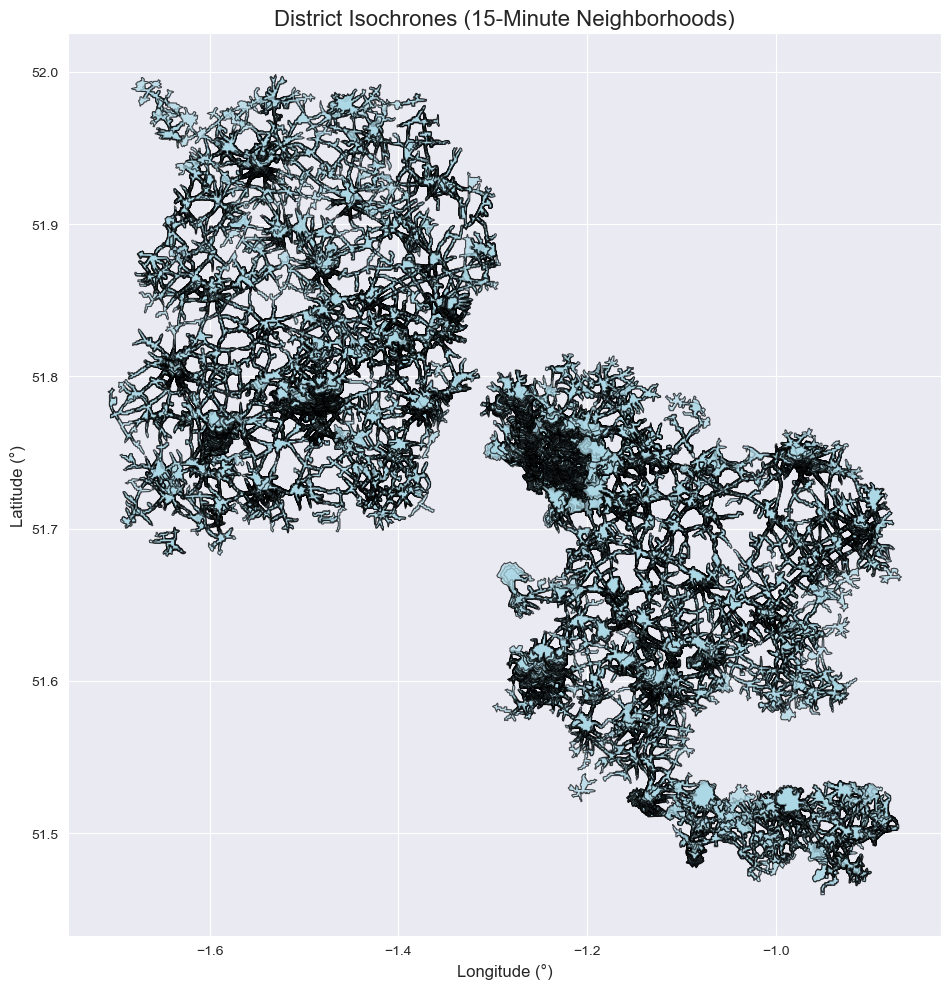

In [25]:
# Load isochrones GeoJSON and convert to CRS
isochrones_path = "data/raw/districts_isochrone.geojson"
isochrones = gpd.read_file(isochrones_path).to_crs(epsg=4326)

# Plot the isochrones
plt.figure(figsize=(12, 10))
isochrones.plot(
    ax=plt.gca(),
    edgecolor="black",
    facecolor="lightblue",
    linewidth=0.8,
    alpha=0.7
)

# Add titles and labels
plt.title("District Isochrones (15-Minute Neighborhoods)", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)

# Display the map
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Dataframe shape
isochrones.shape

(16214, 3)

In [27]:
# Dataframe header values
isochrones.head()

,district,centroid_id,geometry
0,Oxford,743496,"POLYGON ((-1.19599 51.72185, -1.19966 51.72151..."
1,Oxford,743508,"POLYGON ((-1.19657 51.72100, -1.19757 51.72125..."
2,Oxford,743652,"POLYGON ((-1.19766 51.72121, -1.19966 51.72065..."
3,Oxford,743874,"POLYGON ((-1.19398 51.72159, -1.19497 51.72137..."
4,Oxford,743912,"POLYGON ((-1.19400 51.72157, -1.19500 51.72137..."


In [28]:
valuation_gdf = gpd.GeoDataFrame(
    valuation_data_cleaned,
    geometry=gpd.points_from_xy(
        valuation_data_cleaned['Longitude (°)'], valuation_data_cleaned['Latitude (°)']
    ),
    crs="EPSG:4326"
)

# Displaying the first few rows to confirm structure
valuation_gdf.head()

,Capital Valuation (£),Rental Valuation (£),Floor Space (m²),Annual Income (£),Geographic Coordinates (latitude longitude),Postcode,Latitude (°),Longitude (°),Capital Valuation (£/m²),Rental Valuation (£/m²),Income-to-Capital Ratio,Income-to-Rental Ratio,Is_Undervalued,Postcode_Group,geometry
0,434042.0,1345.0,77.0,71800.0,51.7646198 -1.2614062,OX2 6EX,51.764620,-1.261406,5636.909091,17.467532,0.165422,53.382900,False,OX2 6E,POINT (-1.26141 51.76462)
1,997636.0,1345.0,78.0,71800.0,51.7644594 -1.2613801,OX2 6EX,51.764459,-1.261380,12790.205128,17.243590,0.071970,53.382900,False,OX2 6E,POINT (-1.26138 51.76446)
2,784927.0,1345.0,88.0,66600.0,51.7615206 -1.2659198,OX2 6EN,51.761521,-1.265920,8919.625000,15.284091,0.084849,49.516729,False,OX2 6E,POINT (-1.26592 51.76152)
3,855603.0,1345.0,83.0,66600.0,51.761556 -1.2658178,OX2 6EN,51.761556,-1.265818,10308.469880,16.204819,0.077840,49.516729,False,OX2 6E,POINT (-1.26582 51.76156)
4,784927.0,1345.0,88.0,66600.0,51.7615737 -1.2657741,OX2 6EN,51.761574,-1.265774,8919.625000,15.284091,0.084849,49.516729,False,OX2 6E,POINT (-1.26577 51.76157)


In [29]:
# Calculate the 0.5 (50th percentile) and upper quartile
normalized_threshold_50th = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(0.5)
upper_quartile = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(undervalued_floor)
max_value = valuation_data_cleaned['Income-to-Capital Ratio'].max()

print(f"50th Percentile of 'Income-to-Capital Ratio': {normalized_threshold_50th}")
print(f"90th Percentile (Upper Quartile): {upper_quartile}")
print(f"Maximum 'Income-to-Capital Ratio': {max_value}")

chunk_size = 10000

# Chunked spatial join
chunks = [valuation_gdf.iloc[i:i + chunk_size] for i in range(0, len(valuation_gdf), chunk_size)]
joined_chunks = []

for chunk in chunks:
    joined_chunk = gpd.sjoin(chunk, isochrones, how='left', predicate='within')
    joined_chunks.append(joined_chunk)

# Combine all chunks into a single GeoDataFrame
valuation_with_isochrone = pd.concat(joined_chunks, ignore_index=True)

# Step 1: Add Normalized Undervaluation Score
valuation_with_isochrone['Normalized Undervaluation Score'] = np.where(
    valuation_with_isochrone['Income-to-Capital Ratio'] <= normalized_threshold_50th,
    0,  # Peg values in the 0-50% quartile to 0
    np.clip(
        (valuation_with_isochrone['Income-to-Capital Ratio'] - normalized_threshold_50th) /
        (max_value - normalized_threshold_50th) * 10,  # Scale the 50-100% quartile to 0-10
        0,
        10
    )
)

# Step 2: Calculate metrics for each isochrone with the normalized score included
isochrone_metrics = (
    valuation_with_isochrone.groupby('centroid_id')
    .agg(
        **{
            'Average Income-to-Capital Ratio': ('Income-to-Capital Ratio', 'mean'),
            'Percentage Above Upper Quartile (%)': (
                'Income-to-Capital Ratio',
                lambda x: (x > upper_quartile).mean() * 100
            ),
            'Normalized Undervaluation Score': ('Normalized Undervaluation Score', 'mean'),
            'Mean Annual Income (£)': ('Annual Income (£)', 'mean'),
            'Mean Capital Valuation (£/m²)': ('Capital Valuation (£/m²)', 'mean'),
            'Latitude (°)': ('Latitude (°)', 'mean'),
            'Longitude (°)': ('Longitude (°)', 'mean'),
            'Postcode Prefix': ('Postcode', lambda x: x.str[:-3].mode()[0])
        }
    )
    .reset_index()
)

# Step 3: Save the metrics to a CSV
output_path = "data/processed/undervaluation_isochrones.csv"
isochrone_metrics.to_csv(output_path, index=False)

# Step 4: Convert to GeoDataFrame
centroid_points_gdf = gpd.GeoDataFrame(
    isochrone_metrics,
    geometry=gpd.points_from_xy(isochrone_metrics['Longitude (°)'], isochrone_metrics['Latitude (°)']),
    crs="EPSG:4326"
)

print(f"Isochrone metrics saved to {output_path}")

50th Percentile of 'Income-to-Capital Ratio': 0.11765471464827228
90th Percentile (Upper Quartile): 0.16847625365730676
Maximum 'Income-to-Capital Ratio': 0.8544532947139754


MemoryError: Unable to allocate 85.9 MiB for an array with shape (4, 2813890) and data type int64

In [32]:
# Display the first few rows of the updated metrics for review
isochrone_metrics.head()

,centroid_id,Average Income-to-Capital Ratio,Percentage Above Upper Quartile (%),Normalized Undervaluation Score,Mean Annual Income (£),Mean Capital Valuation (£/m²),Latitude (°),Longitude (°),Postcode Prefix
0,709867.0,0.111459,6.060606,0.131777,58242.424242,5664.523537,51.664097,-1.075806,OX44
1,710097.0,0.112647,6.250000,0.145494,59090.625000,5639.082097,51.664062,-1.075925,OX44
2,710788.0,0.108106,4.000000,0.093014,61362.000000,5680.536633,51.664656,-1.078899,OX44
3,711496.0,0.099281,0.000000,0.006189,73300.000000,5001.443209,51.665636,-1.088168,OX44
4,714711.0,0.136072,13.681869,0.308326,58027.363737,4640.995180,51.667380,-1.078887,OX44


In [33]:
# Count postcode group values
isochrone_metrics['Postcode Prefix'].value_counts()

Postcode Prefix
OX4      1786
OX2      1146
OX3      1081
OX44      664
OX33      477
Name: count, dtype: int64

In [34]:
# Print postcode groups
unique_postcode_groups = isochrone_metrics['Postcode Prefix'].unique()
print(unique_postcode_groups)

['OX44 ' 'OX4 ' 'OX33 ' 'OX3 ' 'OX2 ']


In [35]:
# Dataframe shape
isochrone_metrics.shape

(5154, 9)

In [36]:
# Dataframe column names
isochrone_metrics.columns

Index(['centroid_id', 'Average Income-to-Capital Ratio',
       'Percentage Above Upper Quartile (%)',
       'Normalized Undervaluation Score', 'Mean Annual Income (£)',
       'Mean Capital Valuation (£/m²)', 'Latitude (°)', 'Longitude (°)',
       'Postcode Prefix'],
      dtype='object')

C:\Users\Sulay\anaconda3\envs\YT_ENV_LAPTOP\lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


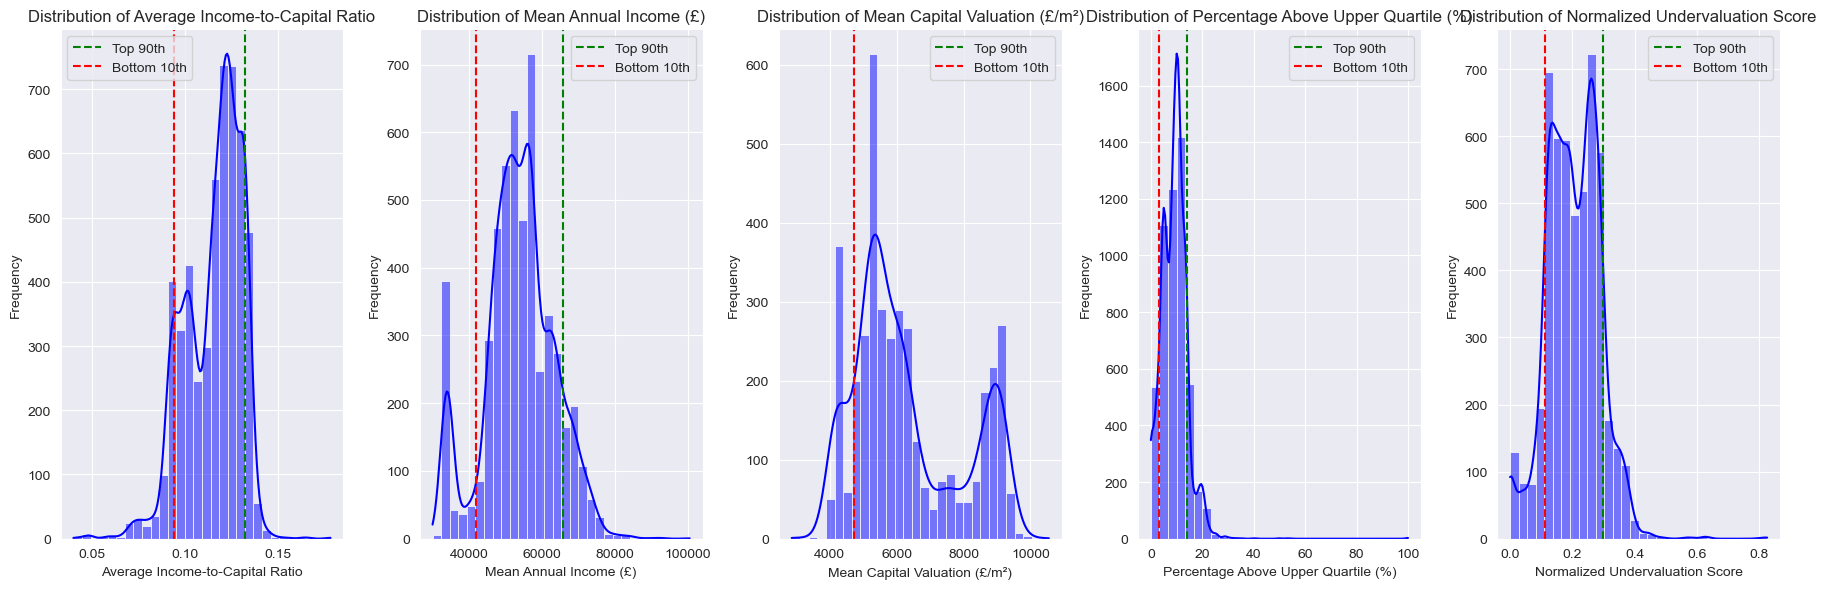

In [37]:
# Calculate percentiles
undervaluation_metrics = ['Average Income-to-Capital Ratio', 'Mean Annual Income (£)', 'Mean Capital Valuation (£/m²)', 'Percentage Above Upper Quartile (%)', 'Normalized Undervaluation Score']
percentiles = {}

for metric in undervaluation_metrics:
    percentiles[metric] = {
        'upper': isochrone_metrics[metric].quantile(undervalued_floor),
        'lower': isochrone_metrics[metric].quantile(overvalued_ceiling)
    }

# Plot histograms
fig_hist_undervaluation, axes_hist_undervaluation = plt.subplots(1, 5, figsize=(18, 6))
for i, metric in enumerate(undervaluation_metrics):
    sns.histplot(isochrone_metrics[metric], kde=True, bins=30, ax=axes_hist_undervaluation[i], color='blue')
    axes_hist_undervaluation[i].axvline(percentiles[metric]['upper'], color='green', linestyle='--', label=f"Top {undervalued_floor*100:.0f}th")
    axes_hist_undervaluation[i].axvline(percentiles[metric]['lower'], color='red', linestyle='--', label=f"Bottom {overvalued_ceiling*100:.0f}th")
    axes_hist_undervaluation[i].set_title(f"Distribution of {metric}")
    axes_hist_undervaluation[i].set_xlabel(metric)
    axes_hist_undervaluation[i].set_ylabel("Frequency")
    axes_hist_undervaluation[i].legend()

plt.tight_layout()
plt.show()

In [38]:
# Check for near-zero or infinite values in the data
print("Checking for problematic values...")

# Define thresholds for near-zero values
near_zero_threshold = 1e-6

# Count rows with near-zero or zero Mean Capital Valuation (£/m²)
near_zero_count = (isochrone_metrics['Mean Capital Valuation (£/m²)'] <= near_zero_threshold).sum()
print(f"Number of rows with near-zero or zero Mean Capital Valuation (£/m²): {near_zero_count}")

# Count rows with infinite Mean Capital Valuation (£/m²)
inf_count = isochrone_metrics['Mean Capital Valuation (£/m²)'].isin([float('inf'), -float('inf')]).sum()
print(f"Number of rows with infinite Mean Capital Valuation (£/m²): {inf_count}")

# Count rows with missing values in key columns
missing_values_count = isochrone_metrics[['Average Income-to-Capital Ratio', 'Mean Annual Income (£)', 'Mean Capital Valuation (£/m²)']].isna().sum()
print("Number of missing values in key columns:")
print(missing_values_count)

Checking for problematic values...
Number of rows with near-zero or zero Mean Capital Valuation (£/m²): 0
Number of rows with infinite Mean Capital Valuation (£/m²): 1200
Number of missing values in key columns:
Average Income-to-Capital Ratio    0
Mean Annual Income (£)             0
Mean Capital Valuation (£/m²)      0
dtype: int64


In [39]:
# Replace inf values with the maximum non-infinite value
print("Replacing infinite values with the maximum non-infinite value...")
max_non_inf_capital = isochrone_metrics.loc[~isochrone_metrics['Mean Capital Valuation (£/m²)'].isin([float('inf'), -float('inf')]), 'Mean Capital Valuation (£/m²)'].max()
isochrone_metrics['Mean Capital Valuation (£/m²)'].replace([float('inf'), -float('inf')], max_non_inf_capital, inplace=True)
print(f"Maximum non-infinite Average_Capital: {max_non_inf_capital}")

Replacing infinite values with the maximum non-infinite value...
Maximum non-infinite Average_Capital: 10549.422413793103


C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\2069731965.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  isochrone_metrics['Mean Capital Valuation (£/m²)'].replace([float('inf'), -float('inf')], max_non_inf_capital, inplace=True)


In [40]:
# Geodataframe header values
centroid_points_gdf.head()

,centroid_id,Average Income-to-Capital Ratio,Percentage Above Upper Quartile (%),Normalized Undervaluation Score,Mean Annual Income (£),Mean Capital Valuation (£/m²),Latitude (°),Longitude (°),Postcode Prefix,geometry
0,709867.0,0.111459,6.060606,0.131777,58242.424242,5664.523537,51.664097,-1.075806,OX44,POINT (-1.07581 51.66410)
1,710097.0,0.112647,6.250000,0.145494,59090.625000,5639.082097,51.664062,-1.075925,OX44,POINT (-1.07592 51.66406)
2,710788.0,0.108106,4.000000,0.093014,61362.000000,5680.536633,51.664656,-1.078899,OX44,POINT (-1.07890 51.66466)
3,711496.0,0.099281,0.000000,0.006189,73300.000000,5001.443209,51.665636,-1.088168,OX44,POINT (-1.08817 51.66564)
4,714711.0,0.136072,13.681869,0.308326,58027.363737,4640.995180,51.667380,-1.078887,OX44,POINT (-1.07889 51.66738)


C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\2423368624.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()


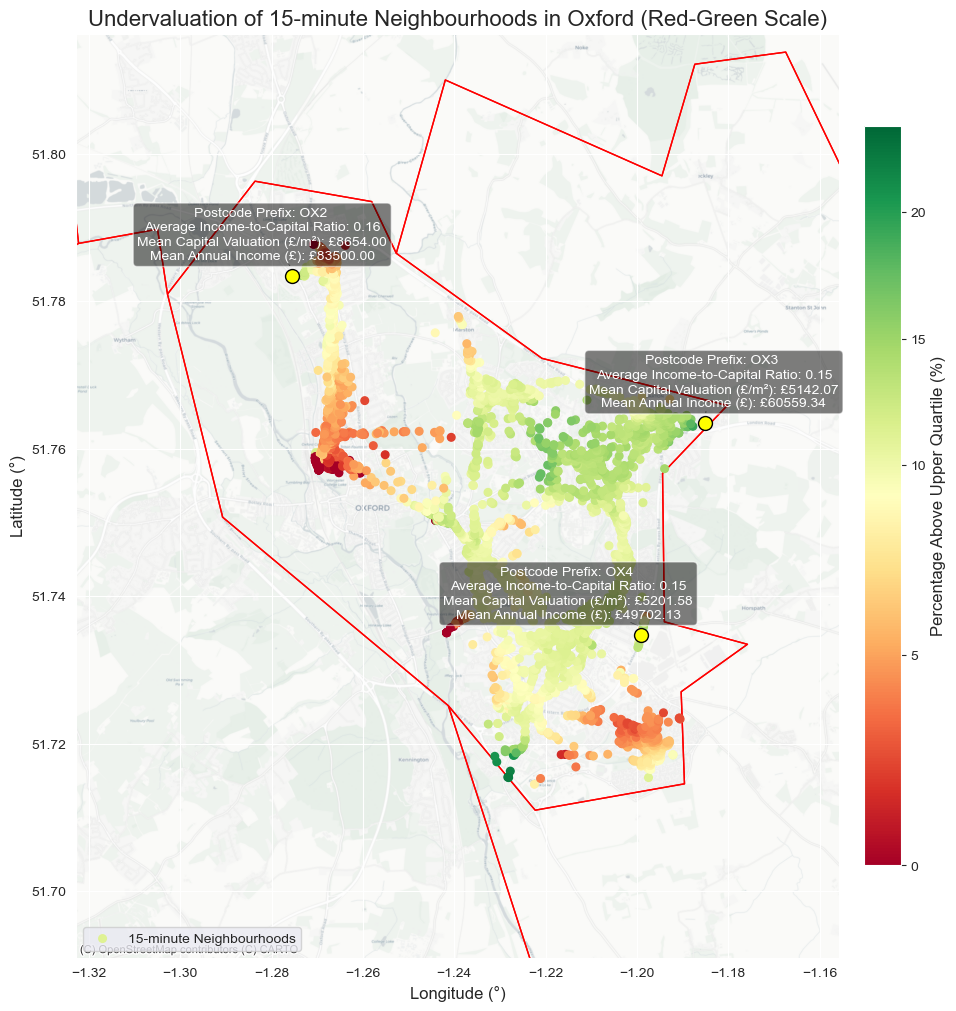

The static map with enhanced red-green colormap has been saved to ../../data/processed/undervaluation_map_neighbourhoods_redgreen_centered.png


In [41]:
# Ensure CRS consistency
selected_districts = selected_districts.to_crs("EPSG:4326")
oxford_district = selected_districts[selected_districts['LAD24CD'] == "E07000178"]
centroid_points_gdf = centroid_points_gdf.to_crs("EPSG:4326")

# Filter points to include only those within Oxford
within_oxford = centroid_points_gdf[
    centroid_points_gdf.geometry.within(oxford_district.unary_union)
]

# Center the colormap on the mean for better value contrast
mean_value = within_oxford['Percentage Above Upper Quartile (%)'].mean()

# Normalize using TwoSlopeNorm for centered scaling
cmap_neighbourhoods = plt.cm.RdYlGn  # Red-Yellow-Green colormap
norm_neighbourhoods = TwoSlopeNorm(
    vmin=within_oxford['Percentage Above Upper Quartile (%)'].min(),
    vcenter=mean_value,  # Centered on the mean for clear value differences
    vmax=within_oxford['Percentage Above Upper Quartile (%)'].max()
)

# Create the Matplotlib figure
fig_neighbourhoods, ax_neighbourhoods = plt.subplots(figsize=(16, 12))

# Use the Oxford district geometry for bounding box with padding
oxford_bounds = oxford_district.total_bounds
x_min, y_min, x_max, y_max = oxford_bounds
padding = 0.02
ax_neighbourhoods.set_xlim(x_min - padding, x_max + padding)
ax_neighbourhoods.set_ylim(y_min - padding, y_max + padding)

# Add grayscale basemap (CartoDB Positron)
ctx.add_basemap(
    ax_neighbourhoods,
    source=ctx.providers.CartoDB.Positron,
    zoom=14,
    crs="EPSG:4326"
)

# Plot all district boundaries in red
selected_districts.plot(ax=ax_neighbourhoods, edgecolor="red", facecolor="none", linewidth=1)

# Plot undervaluation points (Oxford only)
within_oxford.plot(
    ax=ax_neighbourhoods,
    markersize=30,
    color=[cmap_neighbourhoods(norm_neighbourhoods(value)) for value in within_oxford['Percentage Above Upper Quartile (%)']],
    label="15-minute Neighbourhoods"
)

# Helper function to get central point per group
def get_central_point(group):
    if not group.empty and group['Average Income-to-Capital Ratio'].notnull().any():
        return group.loc[group['Average Income-to-Capital Ratio'].idxmax()]
    return None

# Apply grouping for central points
central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()

# Plot central points and add labels
texts = []
for idx, row in central_points.iterrows():
    ax_neighbourhoods.scatter(row.geometry.x, row.geometry.y, color='yellow', s=100, edgecolor='black', label=None)
    texts.append(ax_neighbourhoods.text(
        row.geometry.x, row.geometry.y + 0.001,
        f"Postcode Prefix: {row['Postcode Prefix']}\n"
        f"Average Income-to-Capital Ratio: {row['Average Income-to-Capital Ratio']:.2f}\n"
        f"Mean Capital Valuation (£/m²): £{row['Mean Capital Valuation (£/m²)']:.2f}\n"
        f"Mean Annual Income (£): £{row['Mean Annual Income (£)']:.2f}",
        fontsize=10, ha='center', color='white',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5)
    ))

# Adjust overlapping labels
adjust_text(texts, ax=ax_neighbourhoods, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

# Add colorbar for undervaluation with centered normalization
scm_neighbourhoods = plt.cm.ScalarMappable(cmap=cmap_neighbourhoods, norm=norm_neighbourhoods)
scm_neighbourhoods.set_array([])
cbar_neighbourhoods = plt.colorbar(scm_neighbourhoods, ax=ax_neighbourhoods, orientation="vertical", shrink=0.8, pad=0.02)
cbar_neighbourhoods.set_label("Percentage Above Upper Quartile (%)", fontsize=12)
cbar_neighbourhoods.ax.tick_params(labelsize=10)

# Add title and legend
plt.title("Undervaluation of 15-minute Neighbourhoods in Oxford (Red-Green Scale)", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)
plt.legend(loc="lower left", fontsize=10)

# Save the plot
neighbourhoods_map_path = "outputs/undervaluation_map_neighbourhoods_redgreen_centered.png"
plt.savefig(neighbourhoods_map_path, dpi=400, bbox_inches="tight")
plt.show()

print(f"The static map with enhanced red-green colormap has been saved to {neighbourhoods_map_path}")

C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\296371151.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()
C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\296371151.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower left", fontsize=10)


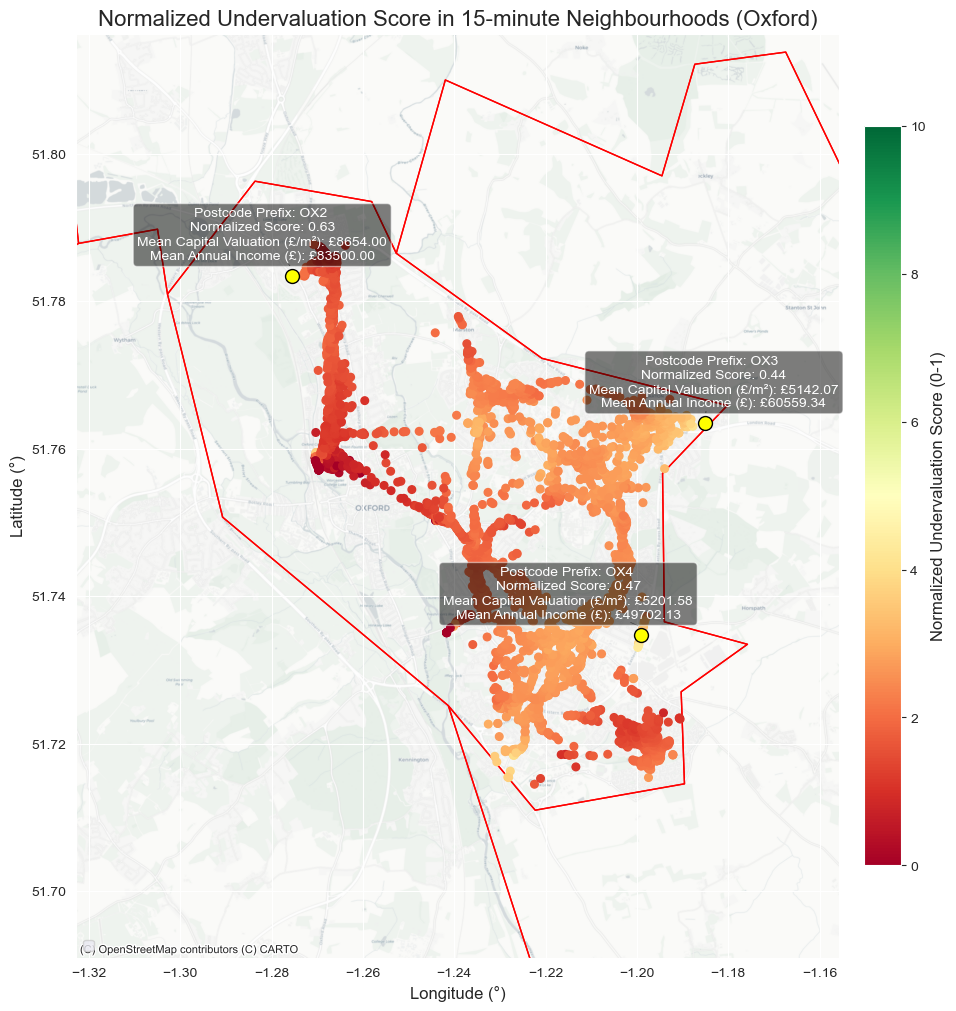

The static map with normalized undervaluation scores has been saved to ../../data/processed/normalized_undervaluation_map_oxford.png.


In [42]:
# Ensure CRS consistency
selected_districts = selected_districts.to_crs("EPSG:4326")
oxford_district = selected_districts[selected_districts['LAD24CD'] == "E07000178"]
centroid_points_gdf = centroid_points_gdf.to_crs("EPSG:4326")

# Filter points to include only those within Oxford
within_oxford = centroid_points_gdf[
    centroid_points_gdf.geometry.within(oxford_district.unary_union)
]

# Define colormap and normalization for the normalized undervaluation score
cmap_normalized = plt.cm.RdYlGn  # Red-Green colormap
norm_normalized = Normalize(vmin=0, vmax=10)

# Create the Matplotlib figure
fig_neighbourhoods, ax_neighbourhoods = plt.subplots(figsize=(16, 12))

# Use the Oxford district geometry for bounding box with padding
oxford_bounds = oxford_district.total_bounds
x_min, y_min, x_max, y_max = oxford_bounds
padding = 0.02
ax_neighbourhoods.set_xlim(x_min - padding, x_max + padding)
ax_neighbourhoods.set_ylim(y_min - padding, y_max + padding)

# Add grayscale basemap (CartoDB Positron)
ctx.add_basemap(
    ax_neighbourhoods,
    source=ctx.providers.CartoDB.Positron,
    zoom=14,
    crs="EPSG:4326"
)

# Plot all district boundaries in red
selected_districts.plot(ax=ax_neighbourhoods, edgecolor="red", facecolor="none", linewidth=1)

# Plot normalized undervaluation points (Oxford only)
within_oxford.plot(
    ax=ax_neighbourhoods,
    markersize=30,
    column='Normalized Undervaluation Score',  # Use the normalized score column
    cmap=cmap_normalized,
    vmin=0,
    vmax=1,
    legend=False
)

# Helper function to get central point per group
def get_central_point(group):
    if not group.empty and group['Average Income-to-Capital Ratio'].notnull().any():
        return group.loc[group['Average Income-to-Capital Ratio'].idxmax()]
    return None

# Apply grouping for central points
central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()

# Plot central points and add labels
texts = []
for idx, row in central_points.iterrows():
    ax_neighbourhoods.scatter(row.geometry.x, row.geometry.y, color='yellow', s=100, edgecolor='black', label=None)
    texts.append(ax_neighbourhoods.text(
        row.geometry.x, row.geometry.y + 0.001,
        f"Postcode Prefix: {row['Postcode Prefix']}\n"
        f"Normalized Score: {row['Normalized Undervaluation Score']:.2f}\n"
        f"Mean Capital Valuation (£/m²): £{row['Mean Capital Valuation (£/m²)']:.2f}\n"
        f"Mean Annual Income (£): £{row['Mean Annual Income (£)']:.2f}",
        fontsize=10, ha='center', color='white',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5)
    ))

# Adjust overlapping labels
adjust_text(texts, ax=ax_neighbourhoods, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

# Add colorbar for normalized undervaluation score
scm_normalized = plt.cm.ScalarMappable(cmap=cmap_normalized, norm=norm_normalized)
scm_normalized.set_array([])
cbar_normalized = plt.colorbar(scm_normalized, ax=ax_neighbourhoods, orientation="vertical", shrink=0.8, pad=0.02)
cbar_normalized.set_label("Normalized Undervaluation Score (0-1)", fontsize=12)
cbar_normalized.ax.tick_params(labelsize=10)

# Add title and legend
plt.title("Normalized Undervaluation Score in 15-minute Neighbourhoods (Oxford)", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)
plt.legend(loc="lower left", fontsize=10)

# Save the plot
normalized_neighbourhoods_map_path = "outputs/normalized_undervaluation_map_oxford.png"
plt.savefig(normalized_neighbourhoods_map_path, dpi=400, bbox_inches="tight")
plt.show()

print(f"The static map with normalized undervaluation scores has been saved to {normalized_neighbourhoods_map_path}.")

C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\295263645.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc="upper right")
C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\295263645.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


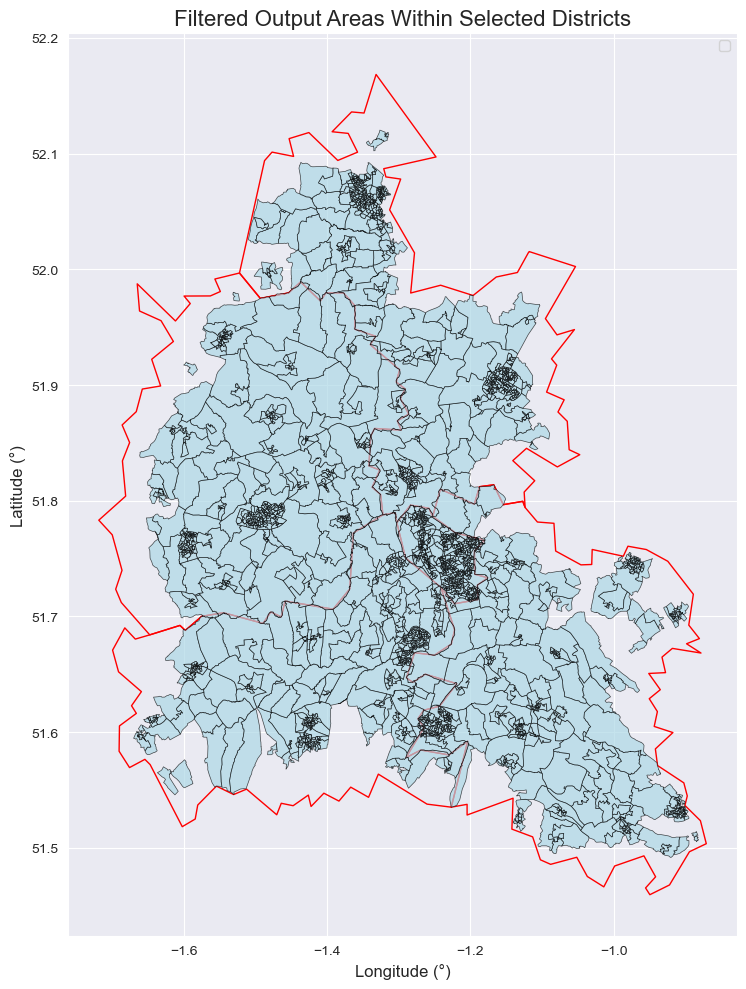

Filtered output areas saved to ../../data/processed/filtered_output_areas.geojson


In [48]:
# Step 1: Load the GeoJSON files
output_areas_path = "data/raw/output_areas.geojson"
selected_districts_path = "data/processed/selected_districts.geojson"

# Load and convert to consistent CRS
output_areas = gpd.read_file(output_areas_path).to_crs(epsg=4326)
selected_districts = gpd.read_file(selected_districts_path).to_crs(epsg=4326)

# Step 2: Spatial join to keep output areas within the selected districts
output_areas_within_districts = output_areas[
    output_areas.geometry.within(selected_districts.unary_union)
]

# Step 3: Plot the filtered output areas
fig, ax = plt.subplots(figsize=(12, 10))
selected_districts.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1, label="Selected Districts")
output_areas_within_districts.plot(
    ax=ax,
    edgecolor="black",
    facecolor="lightblue",
    linewidth=0.5,
    alpha=0.7,
    label="Filtered Output Areas"
)

# Add titles and labels
plt.title("Filtered Output Areas Within Selected Districts", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)
plt.legend(loc="upper right")

# Display the map
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 4: Save the filtered output areas to a new GeoJSON file
filtered_output_areas_path = "data/processed/filtered_output_areas.geojson"
output_areas_within_districts.to_file(filtered_output_areas_path, driver="GeoJSON")

print(f"Filtered output areas saved to {filtered_output_areas_path}")

In [49]:
# Dataframe shape
output_areas_within_districts.shape

(2097, 11)

In [50]:
# Dataframe shape
output_areas_within_districts.head()

,FID,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
137240,137241,E00144833,E01028423,Cherwell 008B,,446793,234246,52.00469,-1.31972,870216a1-2836-4305-9a0e-0ec1a8340424,"POLYGON ((-1.31084 52.01825, -1.31012 52.01819..."
137241,137242,E00144834,E01028423,Cherwell 008B,,446932,234887,52.01044,-1.31761,634bff86-ffd2-42f6-b574-bfce07aa1acb,"POLYGON ((-1.31704 52.01569, -1.31651 52.01444..."
137242,137243,E00144835,E01028423,Cherwell 008B,,446228,234916,52.01076,-1.32786,51e615d6-ba33-4064-9796-8d39519f018d,"POLYGON ((-1.32194 52.01573, -1.32169 52.01432..."
137244,137245,E00144837,E01028422,Cherwell 008A,,446867,236649,52.02629,-1.31832,195134a8-8dcd-469c-918c-aea084f114f9,"POLYGON ((-1.31535 52.03119, -1.31249 52.02681..."
137245,137246,E00144838,E01028422,Cherwell 008A,,448269,235945,52.01984,-1.29798,cd8f1ec1-51d0-46b3-b073-4fba31389b49,"POLYGON ((-1.30331 52.01319, -1.30503 52.01421..."


In [55]:
# Calculate thresholds
normalized_threshold_50th = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(0.5)
upper_quartile = valuation_data_cleaned['Income-to-Capital Ratio'].quantile(undervalued_floor)
max_value = valuation_data_cleaned['Income-to-Capital Ratio'].max()

print(f"50th Percentile of 'Income-to-Capital Ratio': {normalized_threshold_50th}")
print(f"90th Percentile (Upper Quartile): {upper_quartile}")
print(f"Maximum 'Income-to-Capital Ratio': {max_value}")

# Convert valuation data to GeoDataFrame
valuation_gdf = gpd.GeoDataFrame(
    valuation_data_cleaned,
    geometry=gpd.points_from_xy(valuation_data_cleaned['Longitude (°)'], valuation_data_cleaned['Latitude (°)']),
    crs="EPSG:4326"
)

# Chunked spatial join for large datasets
chunk_size = 10000
chunks = [valuation_gdf.iloc[i:i + chunk_size] for i in range(0, len(valuation_gdf), chunk_size)]
joined_chunks = []

for chunk in chunks:
    joined_chunk = gpd.sjoin(chunk, output_areas_within_districts, how='left', predicate='within')
    joined_chunks.append(joined_chunk)

# Combine all chunks into a single GeoDataFrame
valuation_with_output_areas = pd.concat(joined_chunks, ignore_index=True)

# Add Normalized Undervaluation Score
valuation_with_output_areas['Normalized Undervaluation Score'] = np.where(
    valuation_with_output_areas['Income-to-Capital Ratio'] <= normalized_threshold_50th,
    0,  # Peg values in the 0-50% quartile to 0
    np.clip(
        (valuation_with_output_areas['Income-to-Capital Ratio'] - normalized_threshold_50th) /
        (max_value - normalized_threshold_50th) * 10,  # Scale the 50-100% quartile to 0-10
        0, 10
    )
)

# Calculate metrics for each output area
output_area_metrics = (
    valuation_with_output_areas.groupby('FID')
    .agg(
        **{
            'Average Income-to-Capital Ratio': ('Income-to-Capital Ratio', 'mean'),
            'Percentage Above Upper Quartile (%)': (
                'Income-to-Capital Ratio',
                lambda x: (x > upper_quartile).mean() * 100
            ),
            'Normalized Undervaluation Score': ('Normalized Undervaluation Score', 'mean'),
            'Mean Annual Income (£)': ('Annual Income (£)', 'mean'),
            'Mean Capital Valuation (£/m²)': ('Capital Valuation (£/m²)', 'mean'),
            'Latitude (°)': ('Latitude (°)', 'mean'),
            'Longitude (°)': ('Longitude (°)', 'mean'),
            'Postcode Prefix': ('Postcode', lambda x: x.str[:-3].mode()[0])
        }
    )
    .reset_index()
)

# Save metrics to a CSV
output_path = "data/processed/output_area_metrics.csv"
output_area_metrics.to_csv(output_path, index=False)

# Convert to GeoDataFrame for spatial visualization
output_area_points_gdf = gpd.GeoDataFrame(
    output_area_metrics,
    geometry=gpd.points_from_xy(output_area_metrics['Longitude (°)'], output_area_metrics['Latitude (°)']),
    crs="EPSG:4326"
)

print(f"Output area metrics saved to {output_path}")

50th Percentile of 'Income-to-Capital Ratio': 0.11765471464827228
90th Percentile (Upper Quartile): 0.16847625365730676
Maximum 'Income-to-Capital Ratio': 0.8544532947139754
Output area metrics saved to ../../data/processed/output_area_metrics.csv


In [56]:
# Display the first few rows of the updated metrics for review
output_area_metrics.head()

,FID,Average Income-to-Capital Ratio,Percentage Above Upper Quartile (%),Normalized Undervaluation Score,Mean Annual Income (£),Mean Capital Valuation (£/m²),Latitude (°),Longitude (°),Postcode Prefix
0,137598.0,0.115624,7.407407,0.250623,75672.222222,4995.570899,51.812310,-1.209304,OX3
1,137644.0,0.112578,2.877698,0.118126,57802.158273,5982.236435,51.763350,-1.205885,OX3
2,137645.0,0.142505,8.888889,0.353086,47471.851852,4354.355161,51.764108,-1.189736,OX3
3,137646.0,0.126082,13.636364,0.278292,37460.795455,5062.168450,51.764072,-1.197429,OX3
4,137647.0,0.115471,19.259259,0.269634,48582.962963,5689.820579,51.763614,-1.200718,OX3


In [57]:
# Count postcode group values
output_area_metrics['Postcode Prefix'].value_counts()

Postcode Prefix
OX4      187
OX3      137
OX2       64
OX44      31
OX33      21
Name: count, dtype: int64

In [58]:
# Print postcode groups
unique_postcode_groups = output_area_metrics['Postcode Prefix'].unique()
print(unique_postcode_groups)

['OX3 ' 'OX4 ' 'OX2 ' 'OX44 ' 'OX33 ']


In [59]:
# Dataframe shape
output_area_metrics.shape

(440, 9)

In [60]:
# Dataframe column names
output_area_metrics.columns

Index(['FID', 'Average Income-to-Capital Ratio',
       'Percentage Above Upper Quartile (%)',
       'Normalized Undervaluation Score', 'Mean Annual Income (£)',
       'Mean Capital Valuation (£/m²)', 'Latitude (°)', 'Longitude (°)',
       'Postcode Prefix'],
      dtype='object')

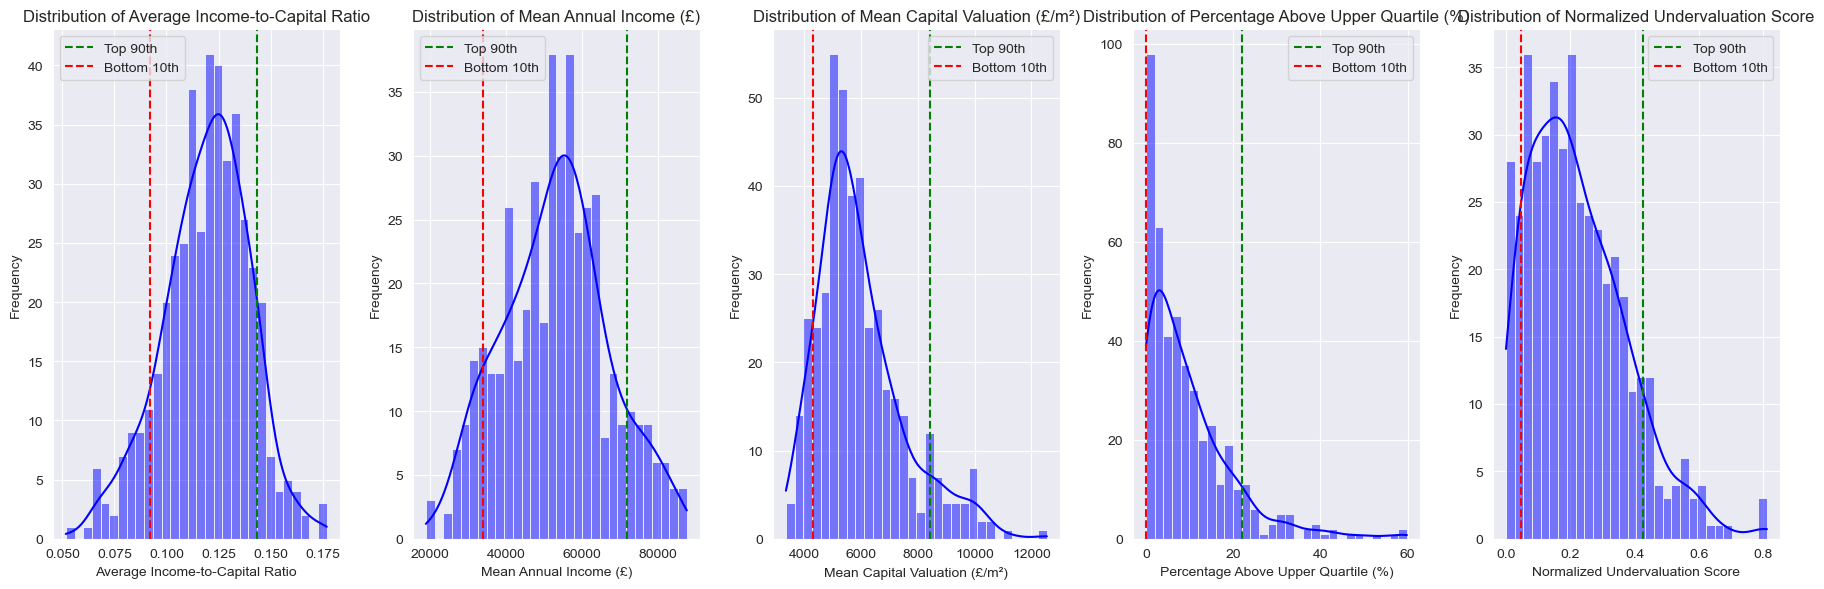

In [61]:
# Calculate percentiles
undervaluation_metrics = ['Average Income-to-Capital Ratio', 'Mean Annual Income (£)', 'Mean Capital Valuation (£/m²)', 'Percentage Above Upper Quartile (%)', 'Normalized Undervaluation Score']
percentiles = {}

for metric in undervaluation_metrics:
    percentiles[metric] = {
        'upper': output_area_metrics[metric].quantile(undervalued_floor),
        'lower': output_area_metrics[metric].quantile(overvalued_ceiling)
    }

# Plot histograms
fig_hist_undervaluation, axes_hist_undervaluation = plt.subplots(1, 5, figsize=(18, 6))
for i, metric in enumerate(undervaluation_metrics):
    sns.histplot(output_area_metrics[metric], kde=True, bins=30, ax=axes_hist_undervaluation[i], color='blue')
    axes_hist_undervaluation[i].axvline(percentiles[metric]['upper'], color='green', linestyle='--', label=f"Top {undervalued_floor*100:.0f}th")
    axes_hist_undervaluation[i].axvline(percentiles[metric]['lower'], color='red', linestyle='--', label=f"Bottom {overvalued_ceiling*100:.0f}th")
    axes_hist_undervaluation[i].set_title(f"Distribution of {metric}")
    axes_hist_undervaluation[i].set_xlabel(metric)
    axes_hist_undervaluation[i].set_ylabel("Frequency")
    axes_hist_undervaluation[i].legend()

plt.tight_layout()
plt.show()

In [62]:
# Check for near-zero or infinite values in the data
print("Checking for problematic values...")

# Define thresholds for near-zero values
near_zero_threshold = 1e-6

# Count rows with near-zero or zero Mean Capital Valuation (£/m²)
near_zero_count = (output_area_metrics['Mean Capital Valuation (£/m²)'] <= near_zero_threshold).sum()
print(f"Number of rows with near-zero or zero Mean Capital Valuation (£/m²): {near_zero_count}")

# Count rows with infinite Mean Capital Valuation (£/m²)
inf_count = output_area_metrics['Mean Capital Valuation (£/m²)'].isin([float('inf'), -float('inf')]).sum()
print(f"Number of rows with infinite Mean Capital Valuation (£/m²): {inf_count}")

# Count rows with missing values in key columns
missing_values_count = output_area_metrics[['Average Income-to-Capital Ratio', 'Mean Annual Income (£)', 'Mean Capital Valuation (£/m²)']].isna().sum()
print("Number of missing values in key columns:")
print(missing_values_count)

Checking for problematic values...
Number of rows with near-zero or zero Mean Capital Valuation (£/m²): 0
Number of rows with infinite Mean Capital Valuation (£/m²): 7
Number of missing values in key columns:
Average Income-to-Capital Ratio    0
Mean Annual Income (£)             0
Mean Capital Valuation (£/m²)      0
dtype: int64


In [64]:
# Replace inf values with the maximum non-infinite value
print("Replacing infinite values with the maximum non-infinite value...")
max_non_inf_capital = output_area_metrics.loc[~output_area_metrics['Mean Capital Valuation (£/m²)'].isin([float('inf'), -float('inf')]), 'Mean Capital Valuation (£/m²)'].max()
output_area_metrics['Mean Capital Valuation (£/m²)'].replace([float('inf'), -float('inf')], max_non_inf_capital, inplace=True)
print(f"Maximum non-infinite Average_Capital: {max_non_inf_capital}")

Replacing infinite values with the maximum non-infinite value...
Maximum non-infinite Average_Capital: 12541.490048198793


C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\1922927237.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  output_area_metrics['Mean Capital Valuation (£/m²)'].replace([float('inf'), -float('inf')], max_non_inf_capital, inplace=True)


In [65]:
# Geodataframe header values
output_area_points_gdf.head()

,FID,Average Income-to-Capital Ratio,Percentage Above Upper Quartile (%),Normalized Undervaluation Score,Mean Annual Income (£),Mean Capital Valuation (£/m²),Latitude (°),Longitude (°),Postcode Prefix,geometry
0,137598.0,0.115624,7.407407,0.250623,75672.222222,4995.570899,51.812310,-1.209304,OX3,POINT (-1.20930 51.81231)
1,137644.0,0.112578,2.877698,0.118126,57802.158273,5982.236435,51.763350,-1.205885,OX3,POINT (-1.20588 51.76335)
2,137645.0,0.142505,8.888889,0.353086,47471.851852,4354.355161,51.764108,-1.189736,OX3,POINT (-1.18974 51.76411)
3,137646.0,0.126082,13.636364,0.278292,37460.795455,5062.168450,51.764072,-1.197429,OX3,POINT (-1.19743 51.76407)
4,137647.0,0.115471,19.259259,0.269634,48582.962963,5689.820579,51.763614,-1.200718,OX3,POINT (-1.20072 51.76361)


C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\1410760101.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()


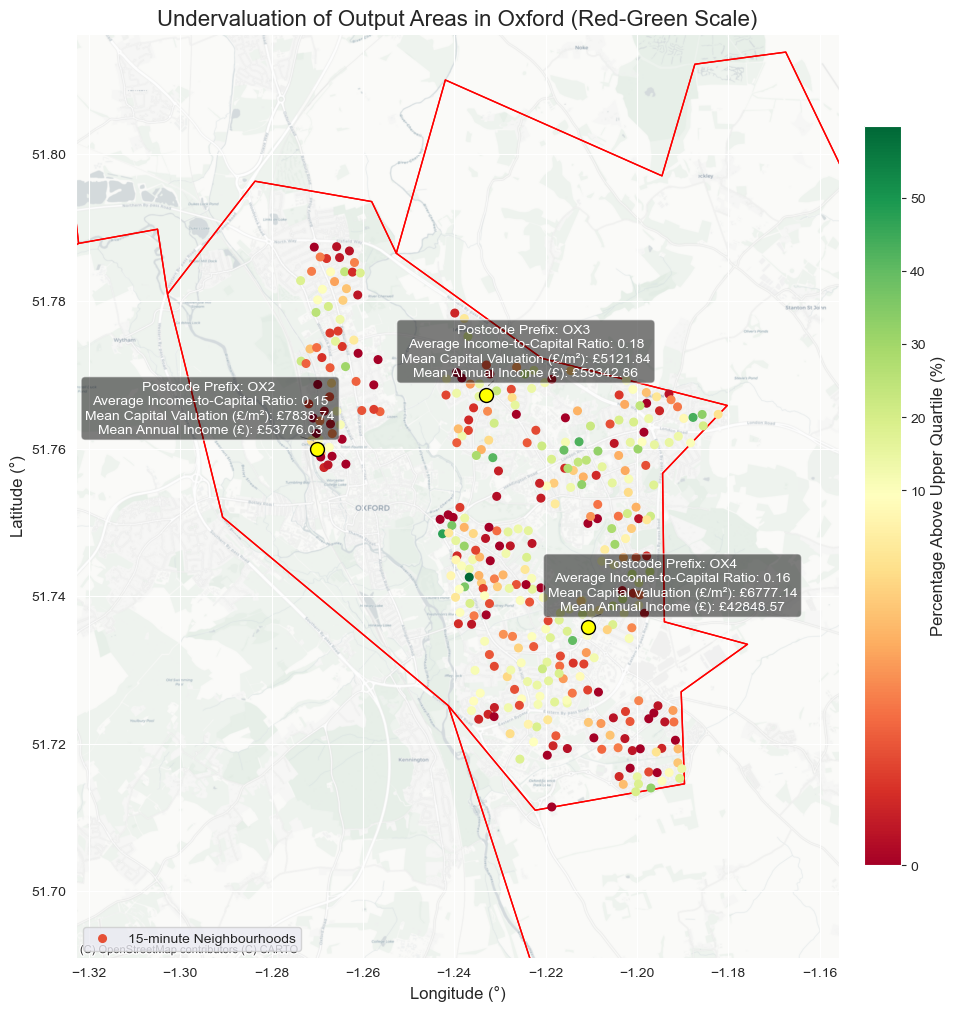

The static map with enhanced red-green colormap has been saved to ../../data/processed/undervaluation_map_output_areas.png


In [75]:
# Ensure CRS consistency
selected_districts = selected_districts.to_crs("EPSG:4326")
oxford_district = selected_districts[selected_districts['LAD24CD'] == "E07000178"]
output_area_points_gdf = output_area_points_gdf.to_crs("EPSG:4326")

# Filter points to include only those within Oxford
within_oxford = output_area_points_gdf[
    output_area_points_gdf.geometry.within(oxford_district.unary_union)
]

# Center the colormap on the mean for better value contrast
mean_value = within_oxford['Percentage Above Upper Quartile (%)'].mean()

# Normalize using TwoSlopeNorm for centered scaling
cmap_neighbourhoods = plt.cm.RdYlGn  # Red-Yellow-Green colormap
norm_neighbourhoods = TwoSlopeNorm(
    vmin=within_oxford['Percentage Above Upper Quartile (%)'].min(),
    vcenter=mean_value,  # Centered on the mean for clear value differences
    vmax=within_oxford['Percentage Above Upper Quartile (%)'].max()
)

# Create the Matplotlib figure
fig_neighbourhoods, ax_neighbourhoods = plt.subplots(figsize=(16, 12))

# Use the Oxford district geometry for bounding box with padding
oxford_bounds = oxford_district.total_bounds
x_min, y_min, x_max, y_max = oxford_bounds
padding = 0.02
ax_neighbourhoods.set_xlim(x_min - padding, x_max + padding)
ax_neighbourhoods.set_ylim(y_min - padding, y_max + padding)

# Add grayscale basemap (CartoDB Positron)
ctx.add_basemap(
    ax_neighbourhoods,
    source=ctx.providers.CartoDB.Positron,
    zoom=14,
    crs="EPSG:4326"
)

# Plot all district boundaries in red
selected_districts.plot(ax=ax_neighbourhoods, edgecolor="red", facecolor="none", linewidth=1)

# Plot undervaluation points (Oxford only)
within_oxford.plot(
    ax=ax_neighbourhoods,
    markersize=30,
    color=[cmap_neighbourhoods(norm_neighbourhoods(value)) for value in within_oxford['Percentage Above Upper Quartile (%)']],
    label="15-minute Neighbourhoods"
)

# Helper function to get central point per group
def get_central_point(group):
    if not group.empty and group['Average Income-to-Capital Ratio'].notnull().any():
        return group.loc[group['Average Income-to-Capital Ratio'].idxmax()]
    return None

# Apply grouping for central points
central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()

# Plot central points and add labels
texts = []
for idx, row in central_points.iterrows():
    ax_neighbourhoods.scatter(row.geometry.x, row.geometry.y, color='yellow', s=100, edgecolor='black', label=None)
    texts.append(ax_neighbourhoods.text(
        row.geometry.x, row.geometry.y + 0.001,
        f"Postcode Prefix: {row['Postcode Prefix']}\n"
        f"Average Income-to-Capital Ratio: {row['Average Income-to-Capital Ratio']:.2f}\n"
        f"Mean Capital Valuation (£/m²): £{row['Mean Capital Valuation (£/m²)']:.2f}\n"
        f"Mean Annual Income (£): £{row['Mean Annual Income (£)']:.2f}",
        fontsize=10, ha='center', color='white',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5)
    ))

# Adjust overlapping labels
adjust_text(texts, ax=ax_neighbourhoods, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

# Add colorbar for undervaluation with centered normalization
scm_neighbourhoods = plt.cm.ScalarMappable(cmap=cmap_neighbourhoods, norm=norm_neighbourhoods)
scm_neighbourhoods.set_array([])
cbar_neighbourhoods = plt.colorbar(scm_neighbourhoods, ax=ax_neighbourhoods, orientation="vertical", shrink=0.8, pad=0.02)
cbar_neighbourhoods.set_label("Percentage Above Upper Quartile (%)", fontsize=12)
cbar_neighbourhoods.ax.tick_params(labelsize=10)

# Add title and legend
plt.title("Undervaluation of Output Areas in Oxford (Red-Green Scale)", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)
plt.legend(loc="lower left", fontsize=10)

# Save the plot
neighbourhoods_map_path = "outputs/undervaluation_map_output_areas.png"
plt.savefig(neighbourhoods_map_path, dpi=400, bbox_inches="tight")
plt.show()

print(f"The static map with enhanced red-green colormap has been saved to {neighbourhoods_map_path}")

C:\Users\Sulay\AppData\Local\Temp\ipykernel_27320\69159835.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()


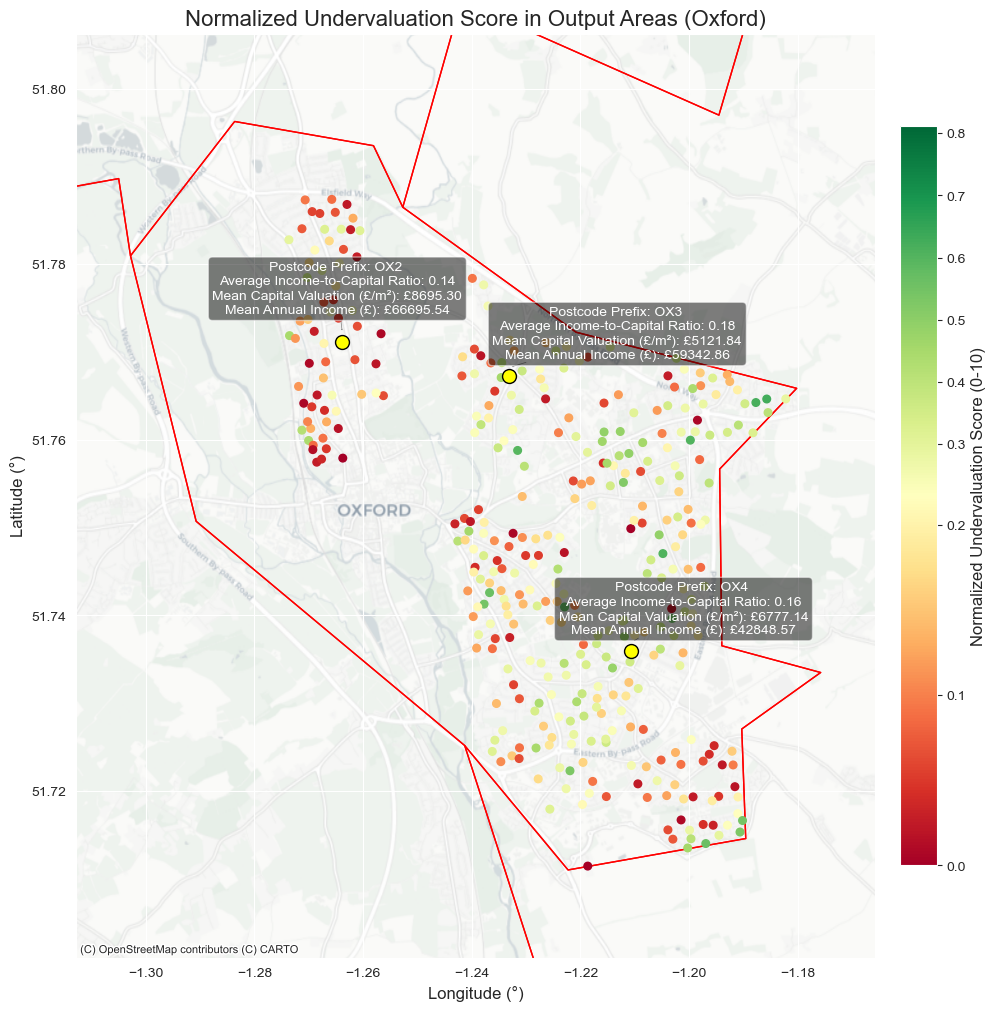

The static map with normalized undervaluation scores has been saved to ../../data/processed/normalized_undervaluation_map_output_areas_oxford.png.


In [78]:
# Center the colormap on the mean for better value contrast
mean_value = within_oxford['Normalized Undervaluation Score'].mean()

# Normalize using TwoSlopeNorm for centered scaling
cmap_neighbourhoods = plt.cm.RdYlGn  # Red-Yellow-Green colormap
norm_neighbourhoods = TwoSlopeNorm(
    vmin=within_oxford['Normalized Undervaluation Score'].min(),
    vcenter=mean_value,  # Centered on the mean for clear value differences
    vmax=within_oxford['Normalized Undervaluation Score'].max()
)

# Create the Matplotlib figure
fig_neighbourhoods, ax_neighbourhoods = plt.subplots(figsize=(16, 12))

# Use the Oxford district geometry for bounding box
oxford_bounds = oxford_district.total_bounds  # [minx, miny, maxx, maxy]
x_min, y_min, x_max, y_max = oxford_bounds
padding = 0.01  # Add slight padding around the bounds

# Set axis limits to center around Oxford
ax_neighbourhoods.set_xlim(x_min - padding, x_max + padding)
ax_neighbourhoods.set_ylim(y_min - padding, y_max + padding)

# Plot all district boundaries in red
selected_districts.plot(ax=ax_neighbourhoods, edgecolor="red", facecolor="none", linewidth=1)

# Plot undervaluation points (Oxford only)
within_oxford.plot(
    ax=ax_neighbourhoods,
    markersize=30,
    color=[cmap_neighbourhoods(norm_neighbourhoods(value)) for value in within_oxford['Normalized Undervaluation Score']],
    label="Output Areas"
)

# Add grayscale basemap (CartoDB Positron)
ctx.add_basemap(
    ax_neighbourhoods,
    source=ctx.providers.CartoDB.Positron,
    zoom=13,  # Adjust zoom for city-level view
    crs="EPSG:4326"
)

# Helper function to get central point per group
def get_central_point(group):
    if not group.empty and group['Normalized Undervaluation Score'].notnull().any():
        return group.loc[group['Normalized Undervaluation Score'].idxmax()]
    return None

# Apply grouping for central points
central_points = within_oxford.groupby('Postcode Prefix').apply(get_central_point).dropna()

# Plot central points and add labels
texts = []
for idx, row in central_points.iterrows():
    ax_neighbourhoods.scatter(row.geometry.x, row.geometry.y, color='yellow', s=100, edgecolor='black', label=None)
    texts.append(ax_neighbourhoods.text(
        row.geometry.x, row.geometry.y + 0.001,
        f"Postcode Prefix: {row['Postcode Prefix']}\n"
        f"Average Income-to-Capital Ratio: {row['Average Income-to-Capital Ratio']:.2f}\n"
        f"Mean Capital Valuation (£/m²): £{row['Mean Capital Valuation (£/m²)']:.2f}\n"
        f"Mean Annual Income (£): £{row['Mean Annual Income (£)']:.2f}",
        fontsize=10, ha='center', color='white',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.5)
    ))

# Adjust overlapping labels
adjust_text(texts, ax=ax_neighbourhoods, arrowprops=dict(arrowstyle="->", color='gray', lw=0.5))

# Add colorbar for undervaluation with centered normalization
scm_neighbourhoods = plt.cm.ScalarMappable(cmap=cmap_neighbourhoods, norm=norm_neighbourhoods)
scm_neighbourhoods.set_array([])
cbar_neighbourhoods = plt.colorbar(scm_neighbourhoods, ax=ax_neighbourhoods, orientation="vertical", shrink=0.8, pad=0.02)
cbar_neighbourhoods.set_label("Normalized Undervaluation Score (0-10)", fontsize=12)
cbar_neighbourhoods.ax.tick_params(labelsize=10)

# Add title and labels
plt.title("Normalized Undervaluation Score in Output Areas (Oxford)", fontsize=16)
plt.xlabel("Longitude (°)", fontsize=12)
plt.ylabel("Latitude (°)", fontsize=12)

# Save the plot
neighbourhoods_map_path = "outputs/normalized_undervaluation_map_output_areas_oxford.png"
plt.savefig(neighbourhoods_map_path, dpi=400, bbox_inches="tight")
plt.show()

print(f"The static map with normalized undervaluation scores has been saved to {neighbourhoods_map_path}.")